<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Diabetes_prediction_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.shape

(768, 9)

In [ ]:
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


EDA for Numerical Features (data_num):


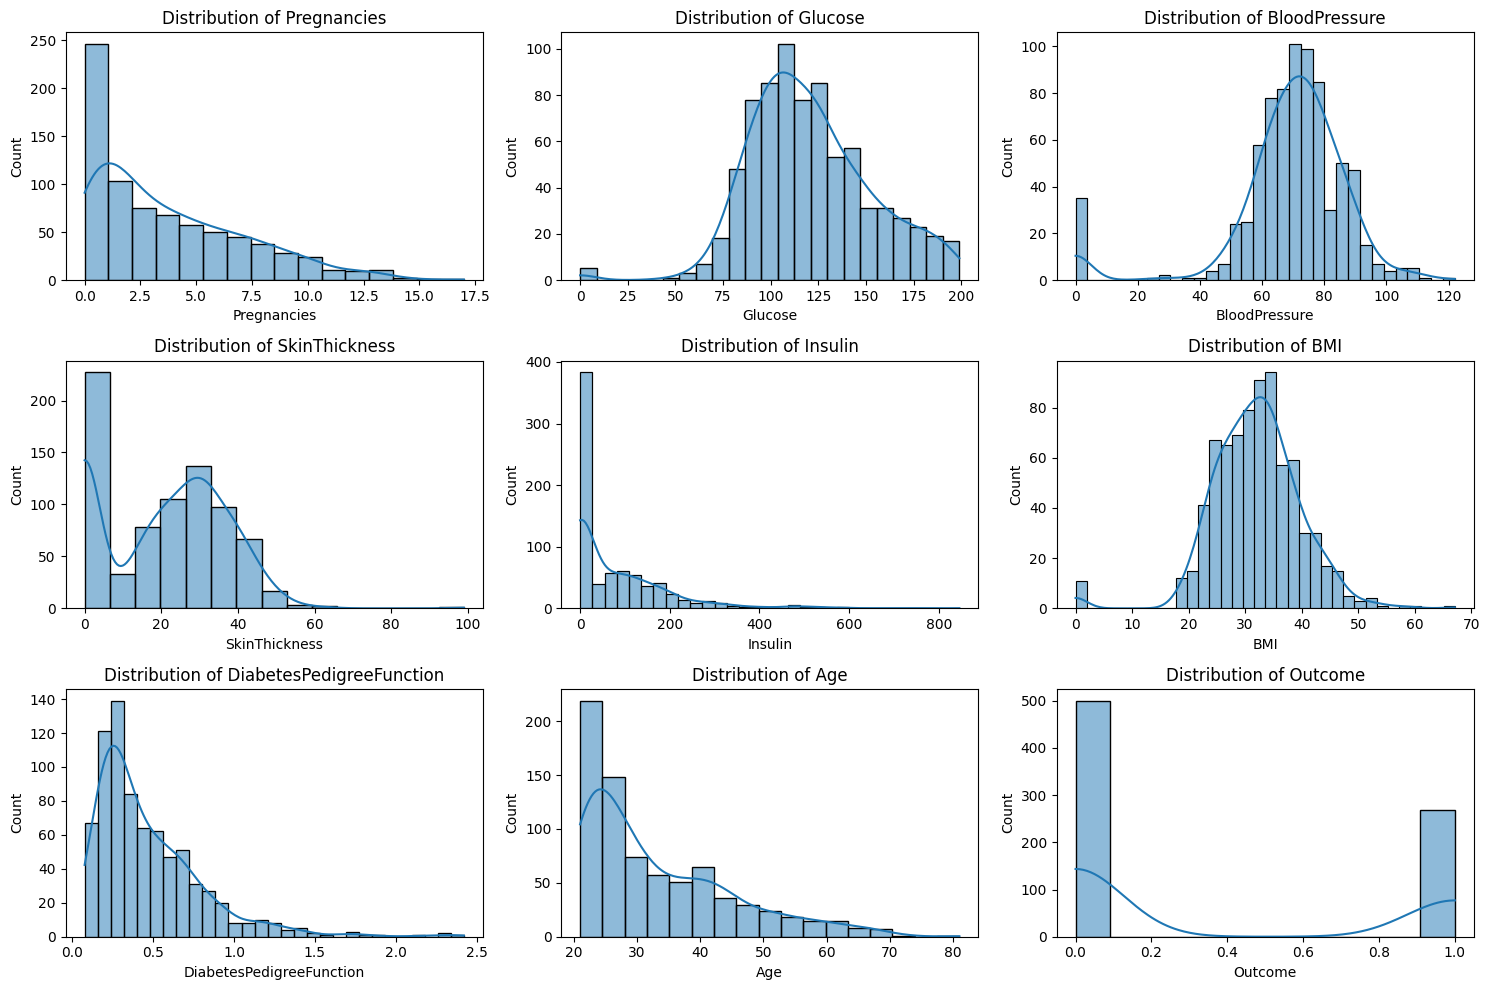

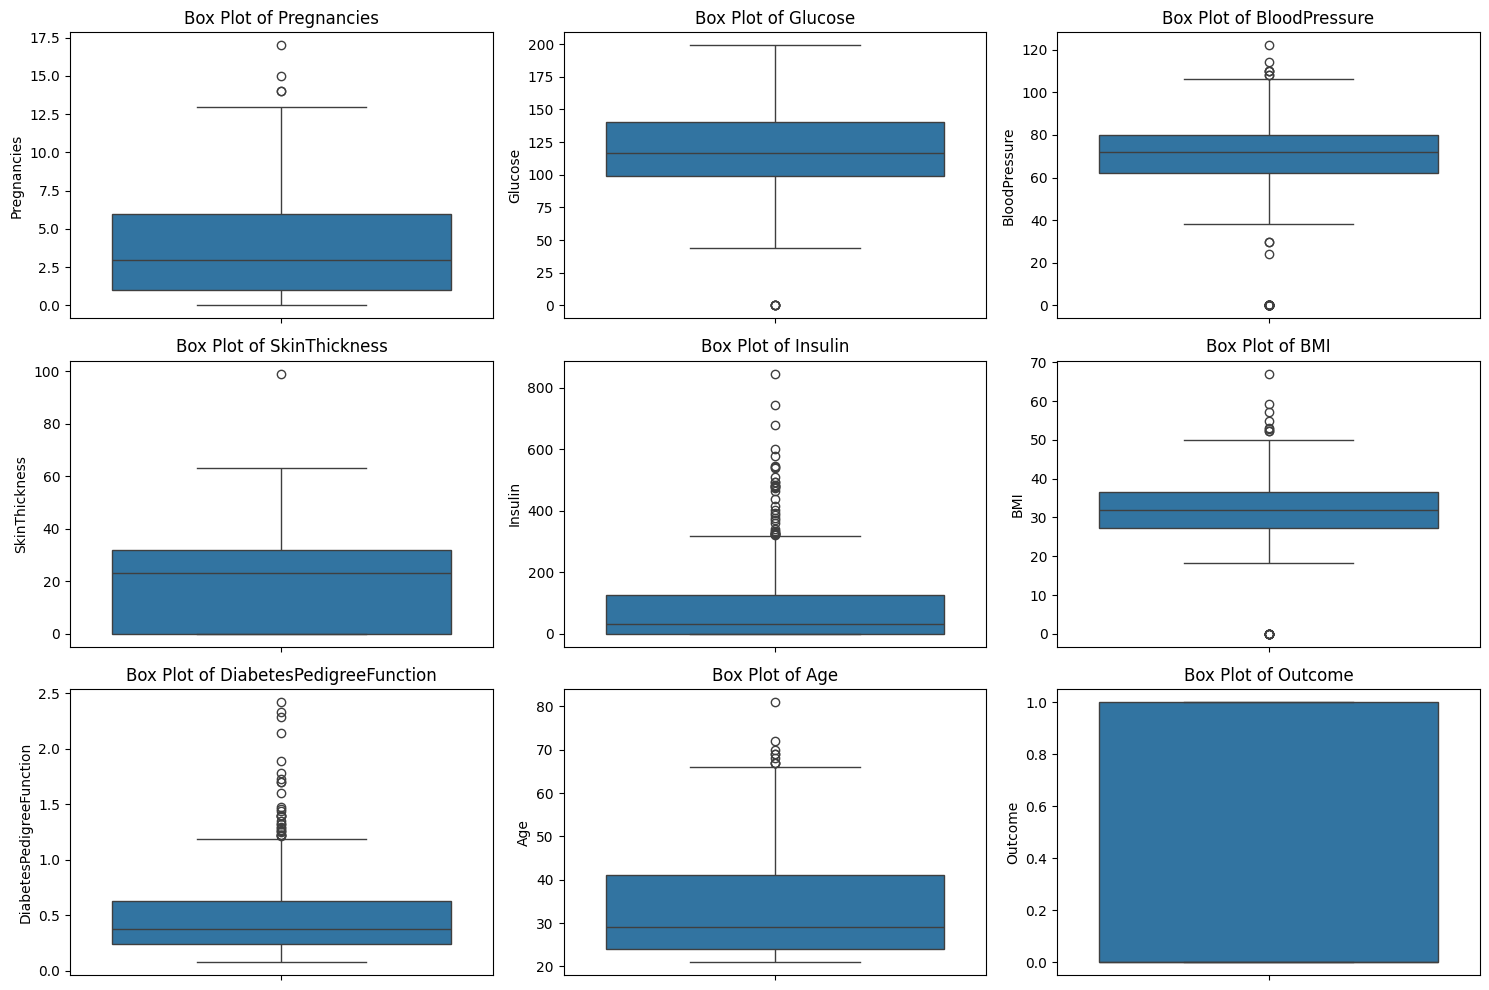

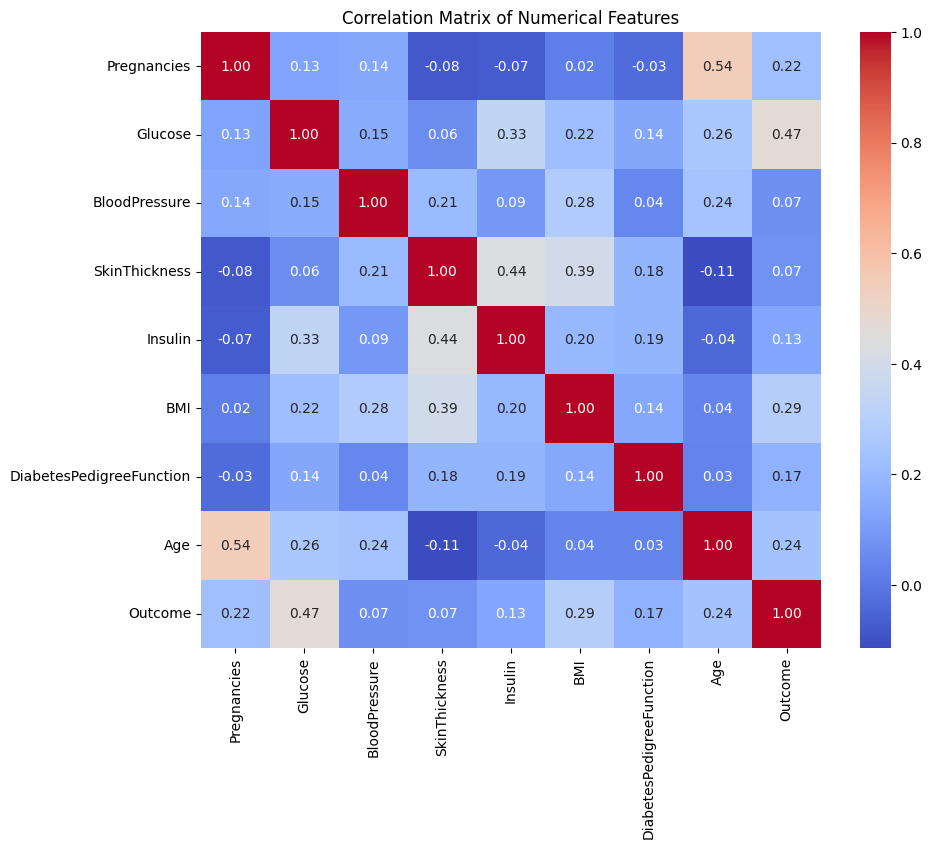

"\nprint('\nEDA for Categorical Features (data_cat):')\n# Count plots for categorical features\nplt.figure(figsize=(25, 10))\nfor i, column in enumerate(eda_cat.columns):\n    plt.subplot(1, 7, i + 1) # Adjust subplot grid based on number of columns\n    sns.countplot(y=eda_cat[column], order = eda_cat[column].value_counts().index)\n    plt.title(f'Count of {column}')\n    plt.tight_layout()\nplt.show()"

In [ ]:
print('EDA for Numerical Features (data_num):')

eda_num = data.select_dtypes(exclude=object)
#eda_cat = data.select_dtypes(include=object)

# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(eda_num[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=eda_num[column])
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
plt.show()

# Correlation Matrix for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(eda_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

'''
print('\nEDA for Categorical Features (data_cat):')
# Count plots for categorical features
plt.figure(figsize=(25, 10))
for i, column in enumerate(eda_cat.columns):
    plt.subplot(1, 7, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(y=eda_cat[column], order = eda_cat[column].value_counts().index)
    plt.title(f'Count of {column}')
    plt.tight_layout()
plt.show()'''

There are no object so no need to exclude object but useful to know when there is a categorical variable like gender

In [ ]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()

# Apply StandardScaler to selected numerical feature columns
X_train_num = pd.DataFrame(
    std_scaler.fit_transform(X_train[X.columns]),
    columns=X.columns,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    std_scaler.transform(X_test[X.columns]),   # transform only — no fit
    columns=X.columns,
    index=X_test.index
)
#end

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=10,
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_res).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
Outcome
0    500
1    268
Name: count, dtype: int64

Training data:
Outcome
1    400
0    400
Name: count, dtype: int64

Testing data:
Outcome
0    100
1     54
Name: count, dtype: int64


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=8)

X_train_pca = pd.DataFrame(
    pca.fit_transform(X_train_res)
)
X_test_pca  = pd.DataFrame(
     pca.transform(X_test)
 )

In [ ]:
! pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = [
    LogisticRegression(),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    DecisionTreeClassifier(max_leaf_nodes=3),
    DecisionTreeClassifier(max_leaf_nodes=10),
    DecisionTreeClassifier(max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1)
]

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize Stratified KFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state= 42)

# Evaluate each model using Stratified KFold cross-validation
results = []

for model in models:
    # Use X_train_res (SMOTEd features) and y_train_res (SMOTEd target) for cross-validation
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=kf, scoring='f1')
    cv_scores = pd.DataFrame(cv_scores)

    print(model)
    display(cv_scores.describe().T)
    print()
# end

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LogisticRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.745805,0.046024,0.692308,0.705128,0.751592,0.787097,0.792899



KNeighborsClassifier(n_neighbors=1)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.781049,0.036322,0.733333,0.768293,0.768362,0.817073,0.818182


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:07:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:07:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:07:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:07:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWar

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.795223,0.02303,0.757764,0.795031,0.795322,0.811429,0.816568



AdaBoostClassifier(learning_rate=0.1, n_estimators=100)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.79402,0.036469,0.7375,0.789809,0.8,0.804469,0.838323


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



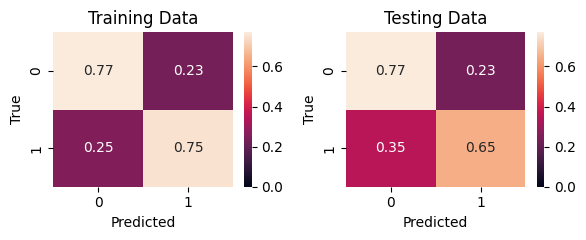

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       100
           1       0.59      0.63      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154



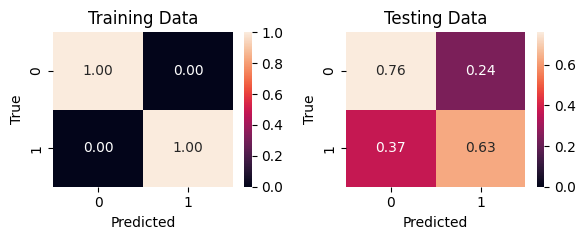

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.78      0.71      0.74       100
           1       0.54      0.63      0.58        54

    accuracy                           0.68       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.70      0.68      0.69       154



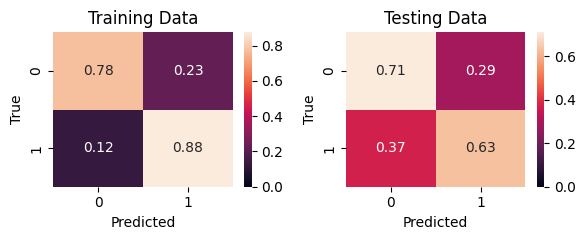

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       100
           1       0.57      0.59      0.58        54

    accuracy                           0.70       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.70      0.70       154



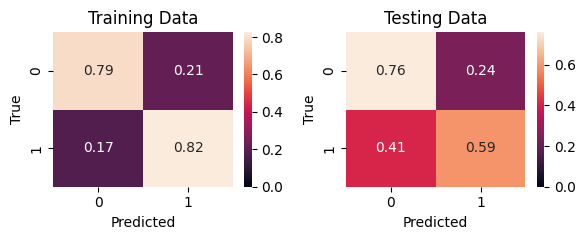

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       100
           1       0.61      0.67      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



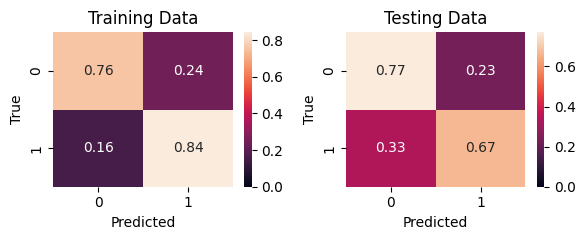

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       100
           1       0.63      0.70      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



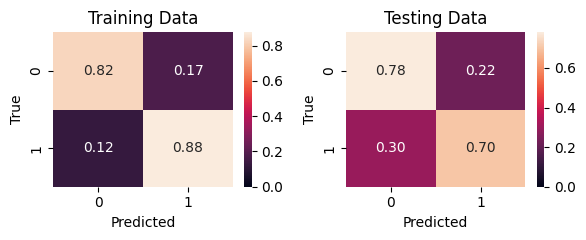

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



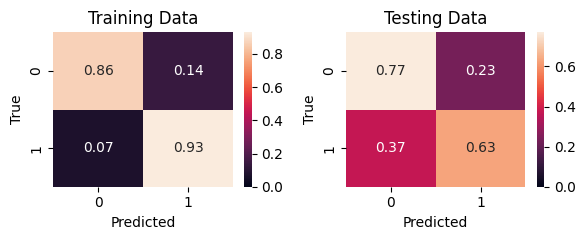

DecisionTreeClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.80      0.68      0.74       100
           1       0.54      0.69      0.60        54

    accuracy                           0.68       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.71      0.68      0.69       154



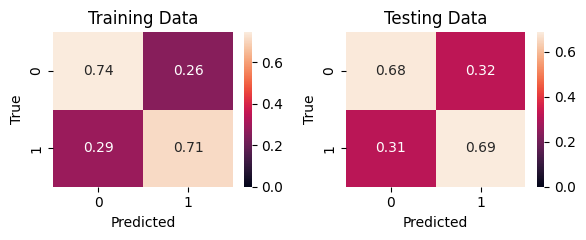

DecisionTreeClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154



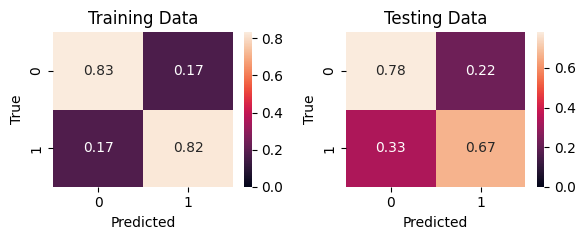

DecisionTreeClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.62      0.59      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



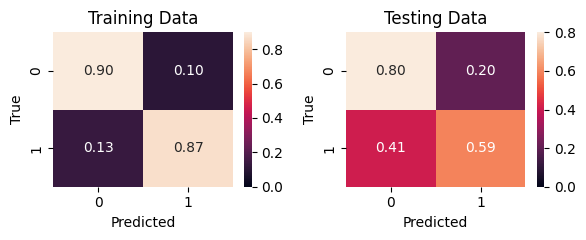

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       100
           1       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



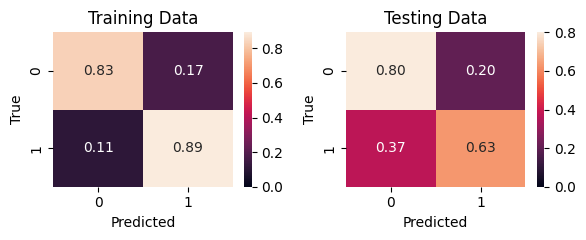

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       100
           1       0.61      0.61      0.61        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



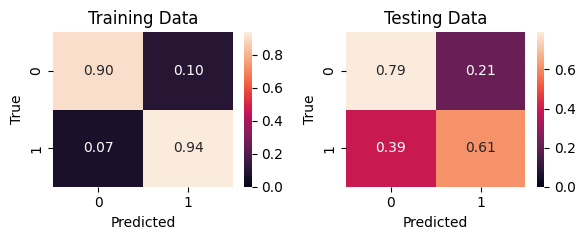

GradientBoostingClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       100
           1       0.61      0.61      0.61        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



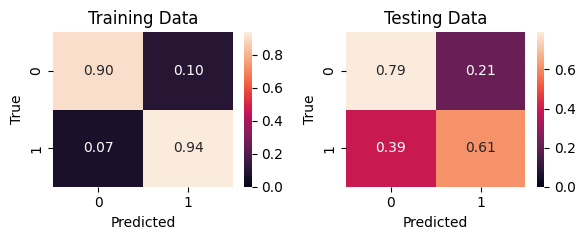

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:09:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=3, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0

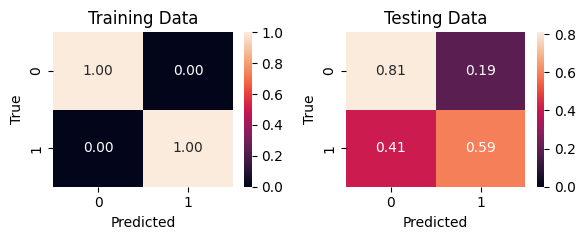

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:09:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=10, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      

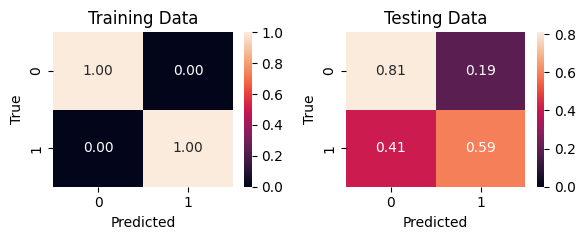

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:09:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      

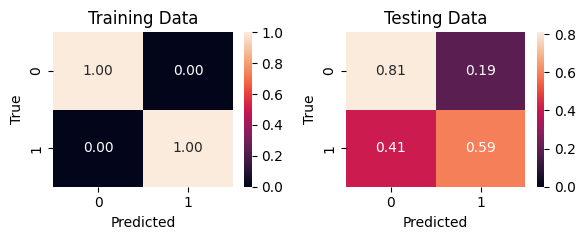

AdaBoostClassifier(learning_rate=0.1, n_estimators=100)
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



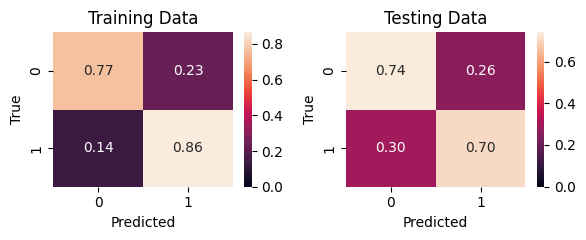

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train_res, y_train_res)
    y_train_pred = m.predict(X_train_res)
    y_test_pred = m.predict(X_test)

    print(m)
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train_res, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    conf_matrix_train = conf_matrix_train.astype(float)
    conf_matrix_test  = conf_matrix_test.astype(float)
    for i in range(conf_matrix_train.shape[0]):
        conf_matrix_train[i,:] = conf_matrix_train[i,:] / conf_matrix_train[i,:].sum()
        conf_matrix_test[i,:]  = conf_matrix_test[i,:] / conf_matrix_test[i,:].sum()
    # end

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end


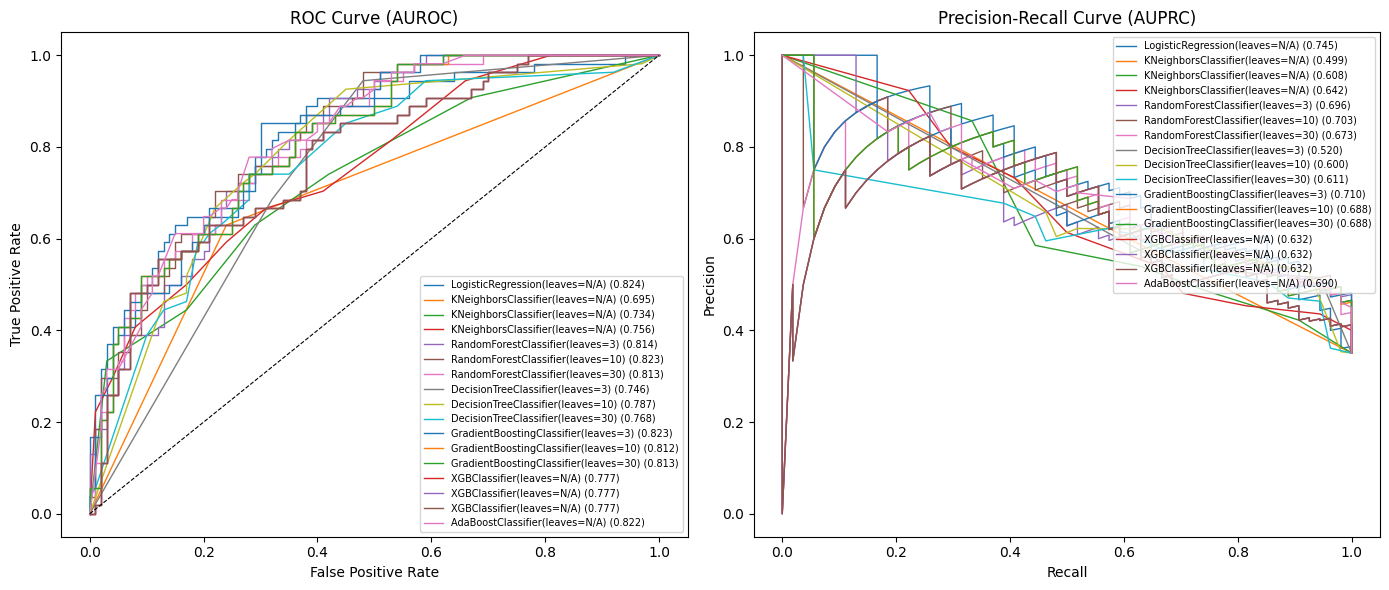

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, matthews_corrcoef

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for m in models:
    y_prob = m.predict_proba(X_test)[:, 1]
    name = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', 'N/A')})"

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({auroc:.3f})", linewidth=1)

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall_vals, precision_vals, label=f"{name} ({ap:.3f})", linewidth=1)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve (AUROC)')
axes[0].legend(fontsize=7, loc='lower right')

axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve (AUPRC)')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

model_to_evaluate = models[0] # Currently Decision Tree Max Node 3, Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)
print("AUPRC:", auprc)
print("AUROC:", auroc)

AUPRC: 0.7453270201031648
AUROC: 0.8235185185185185


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: LogisticRegression(leaves=N/A)
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



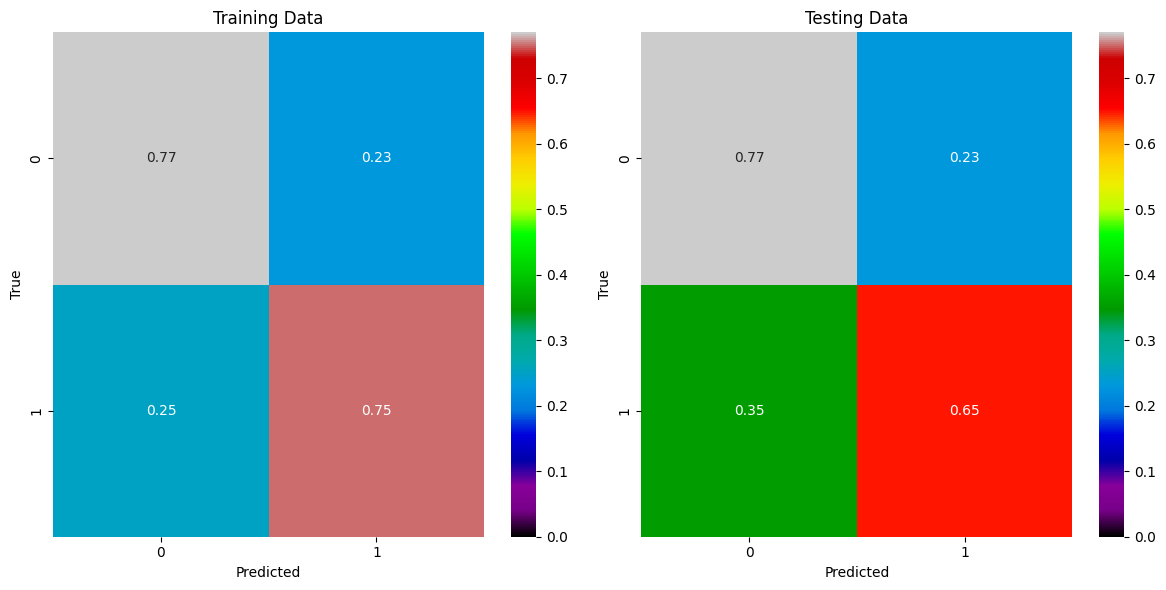


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       100
           1       0.59      0.63      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154



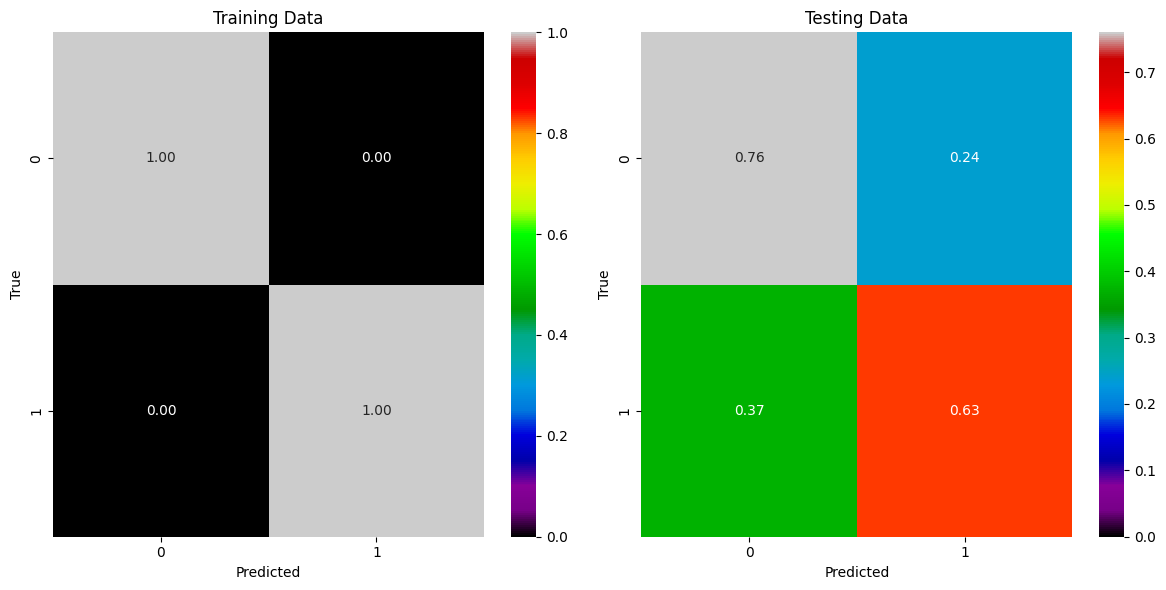


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.78      0.71      0.74       100
           1       0.54      0.63      0.58        54

    accuracy                           0.68       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.70      0.68      0.69       154



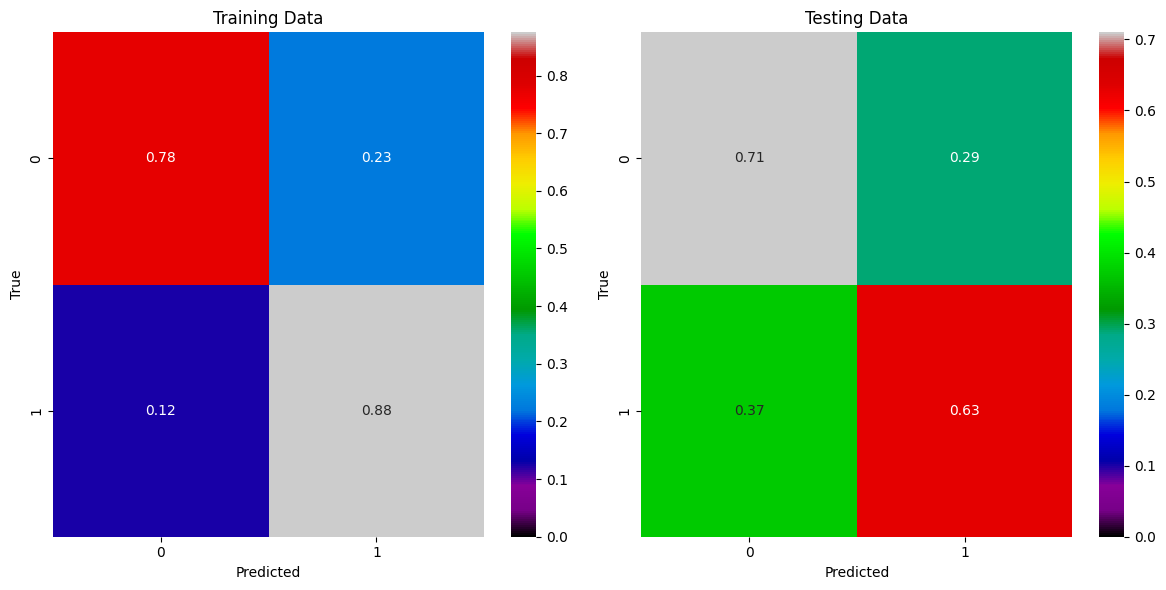


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       100
           1       0.57      0.59      0.58        54

    accuracy                           0.70       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.70      0.70       154



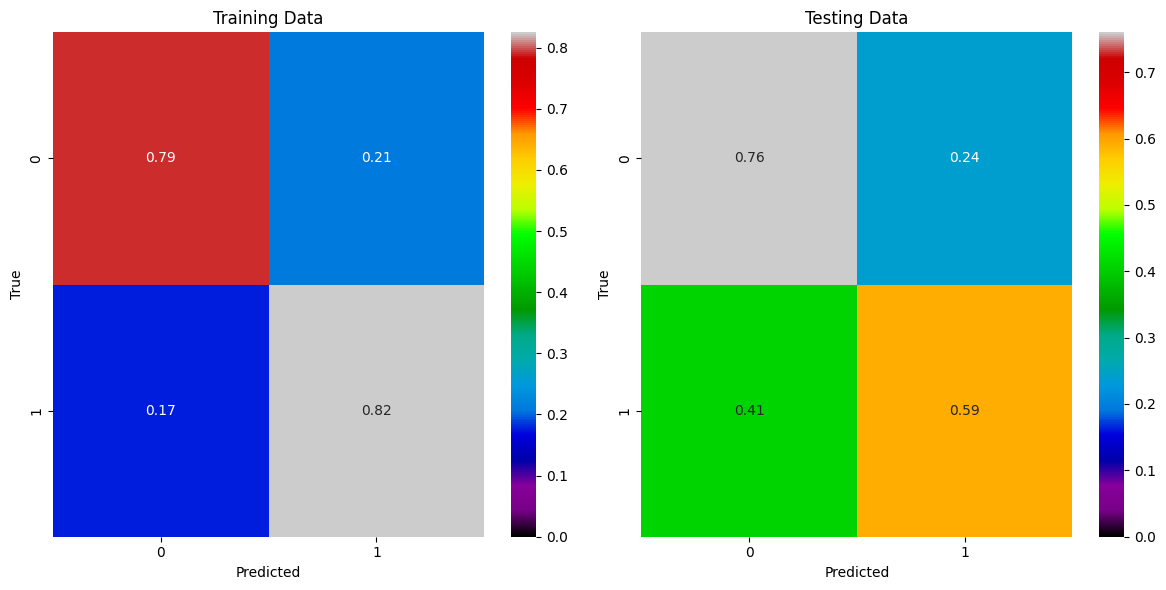


Model: RandomForestClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       100
           1       0.59      0.63      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154



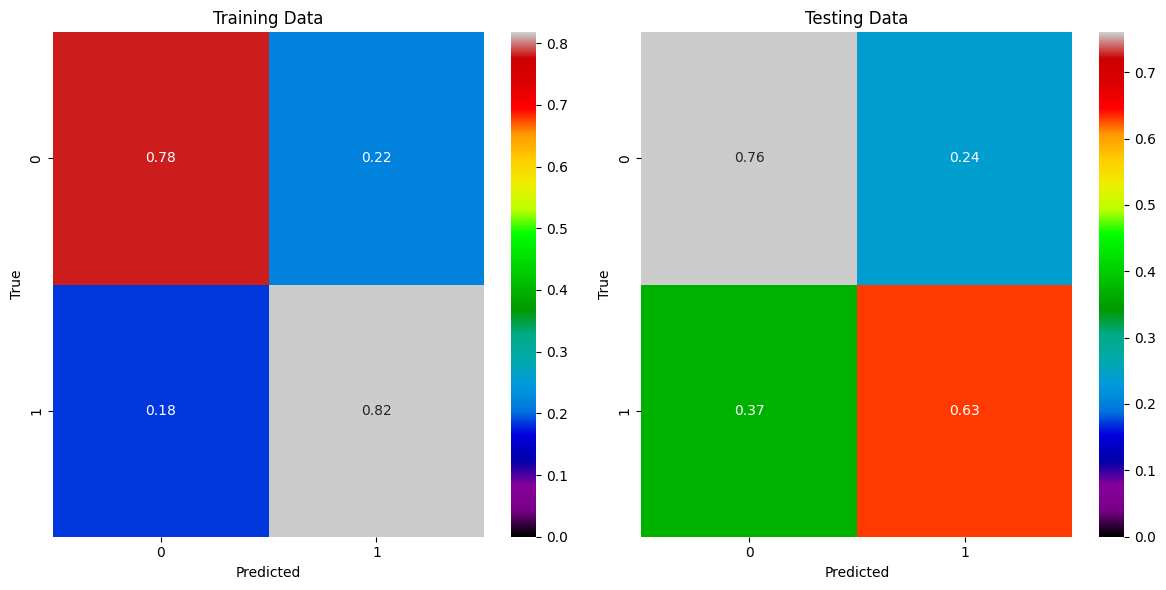


Model: RandomForestClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       100
           1       0.59      0.65      0.62        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.72      0.72       154



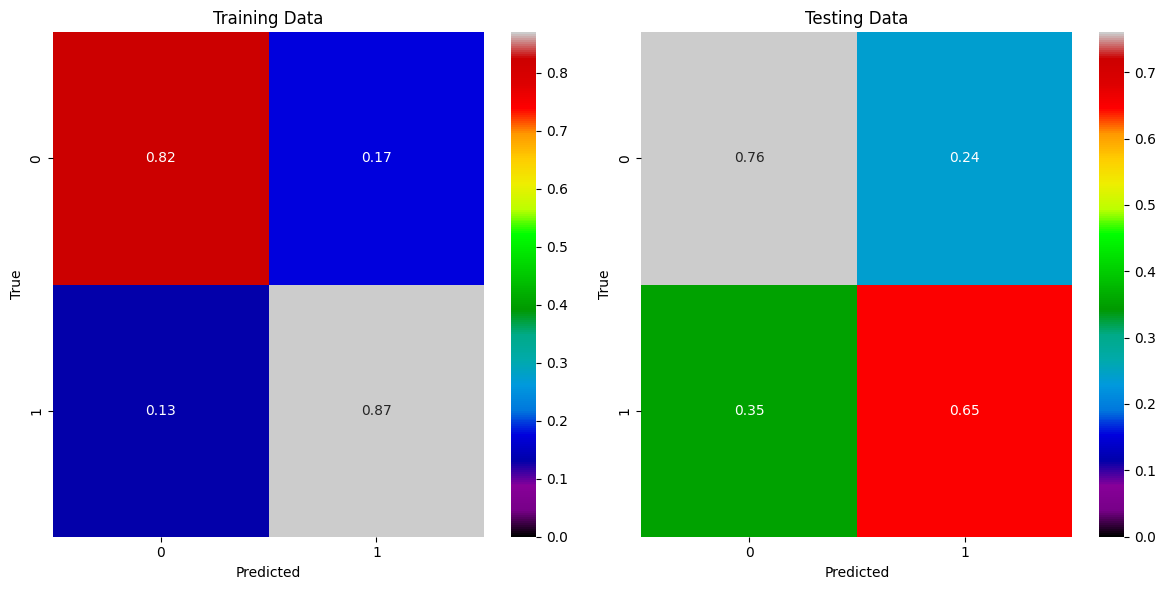


Model: RandomForestClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       100
           1       0.59      0.65      0.62        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.72      0.72       154



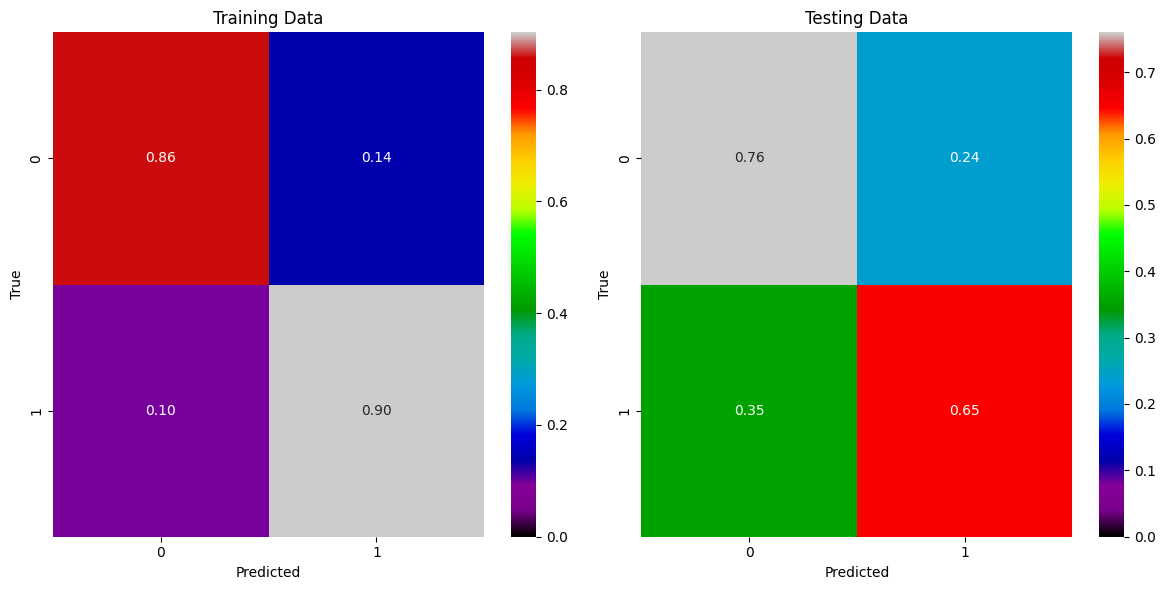


Model: DecisionTreeClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.80      0.68      0.74       100
           1       0.54      0.69      0.60        54

    accuracy                           0.68       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.71      0.68      0.69       154



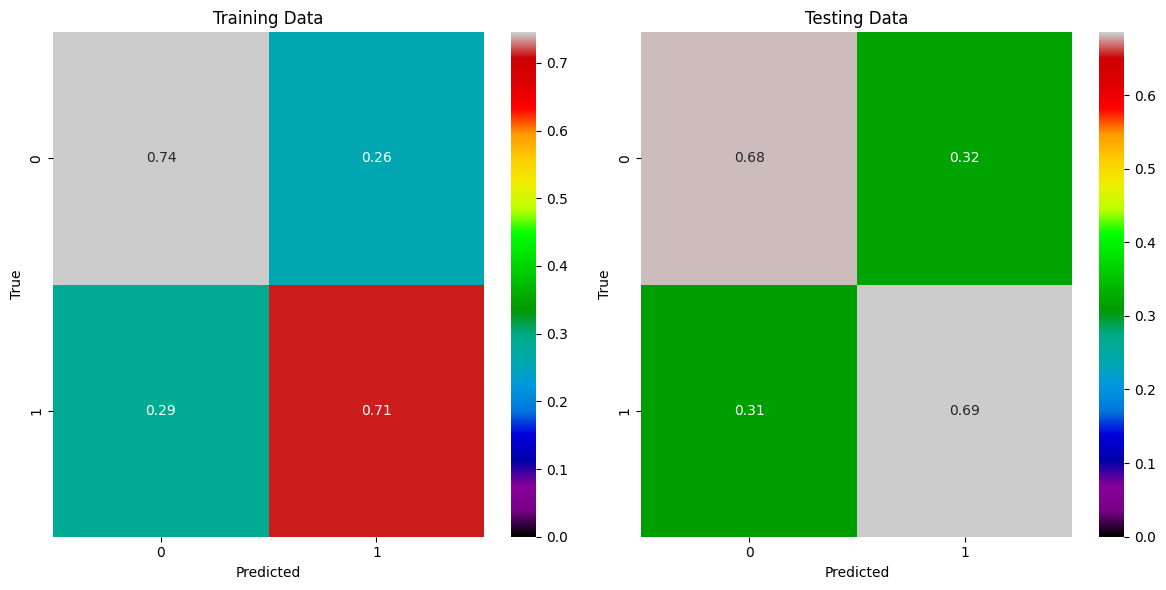


Model: DecisionTreeClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154



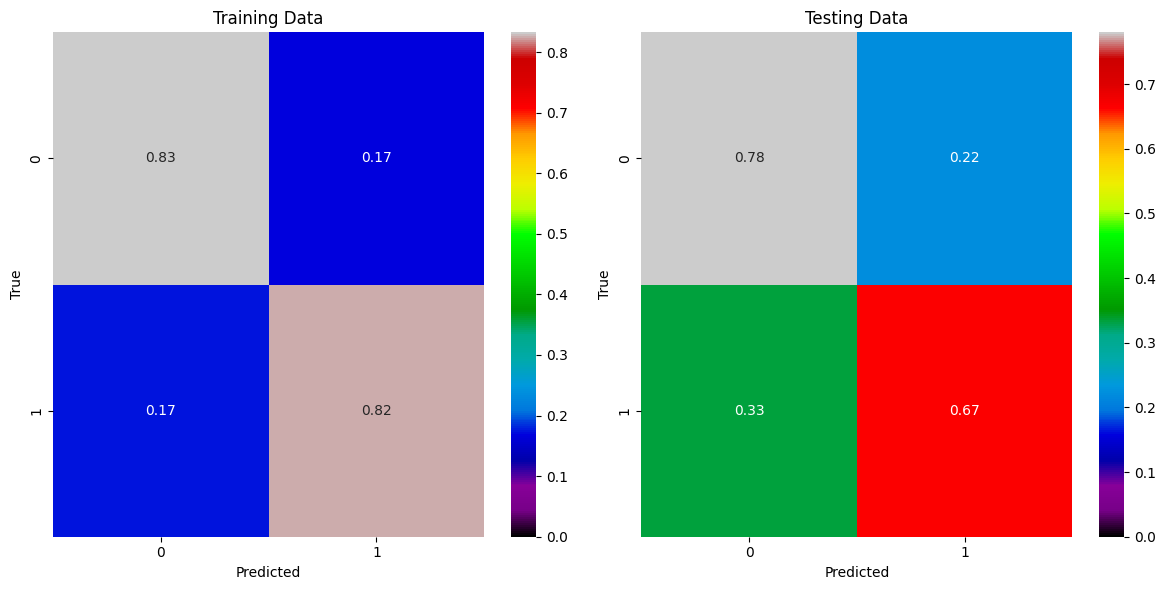


Model: DecisionTreeClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.62      0.59      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



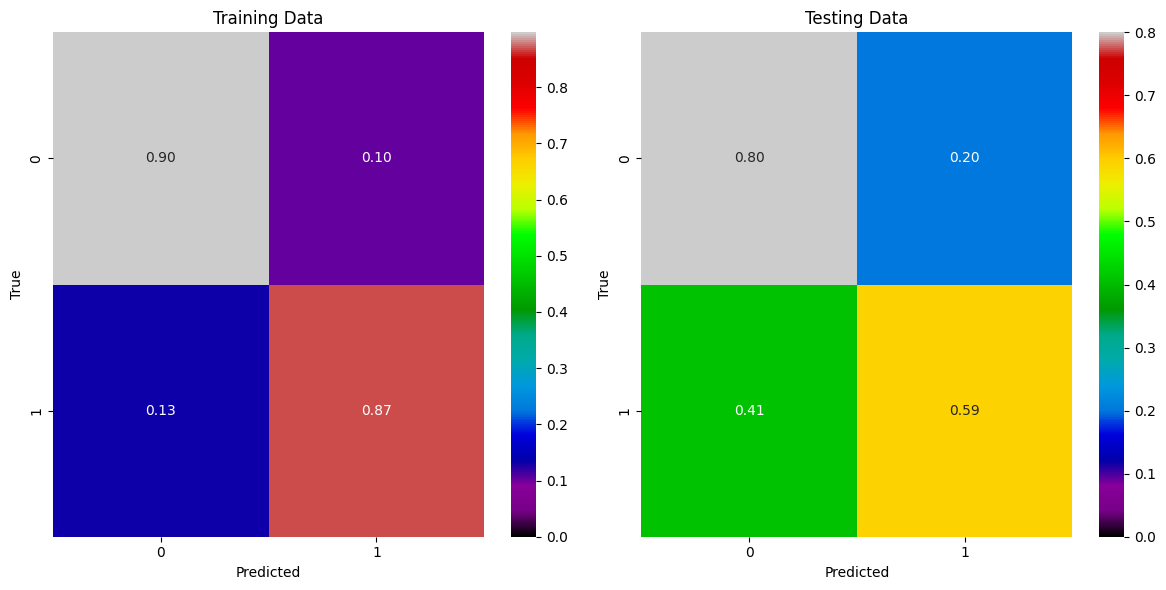


Model: GradientBoostingClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       100
           1       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



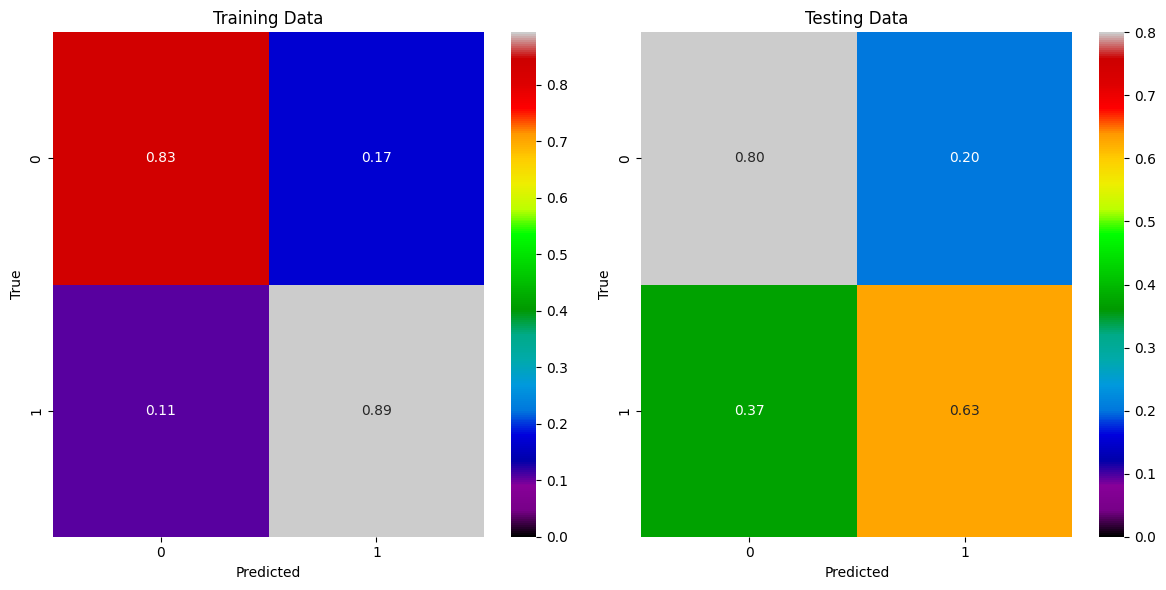


Model: GradientBoostingClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       100
           1       0.60      0.61      0.61        54

    accuracy                           0.72       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.72      0.72       154



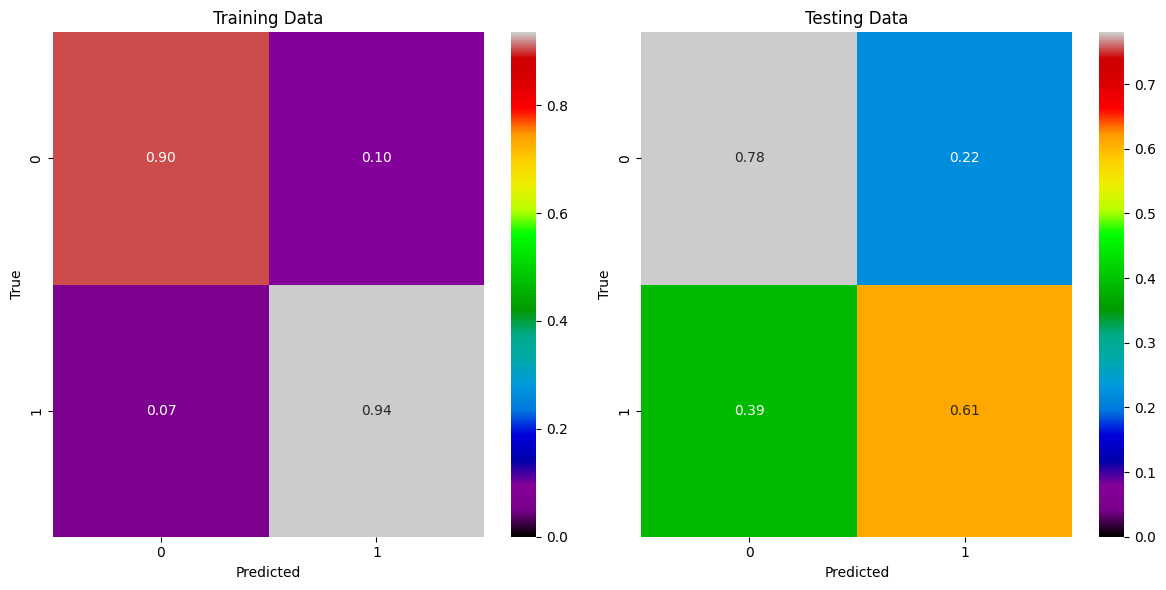


Model: GradientBoostingClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       100
           1       0.60      0.61      0.61        54

    accuracy                           0.72       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.72      0.72       154



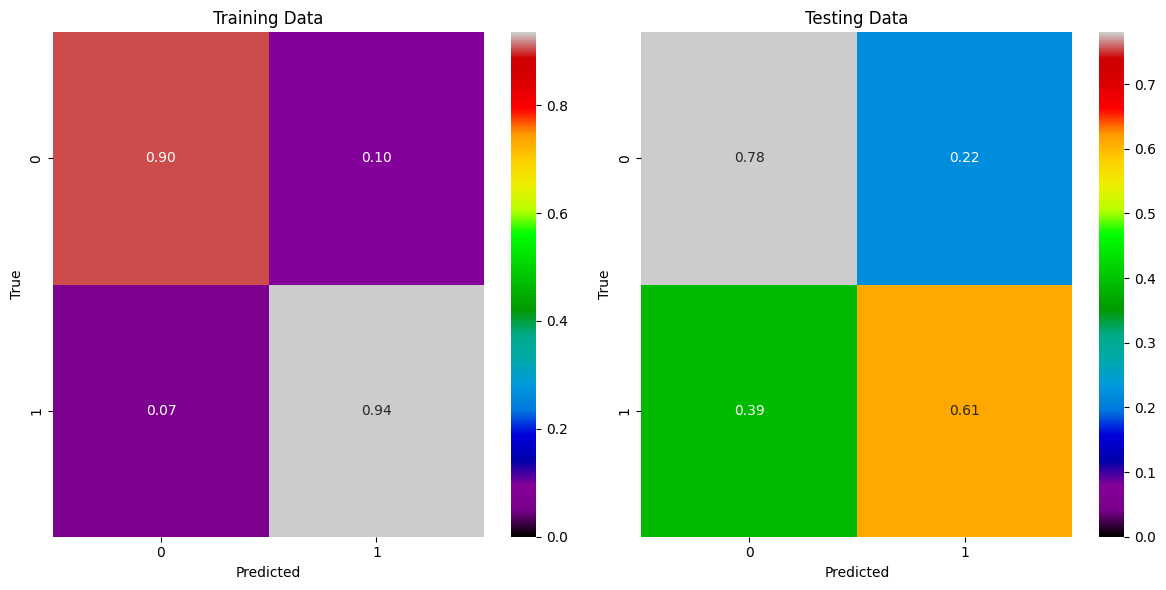

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:10:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



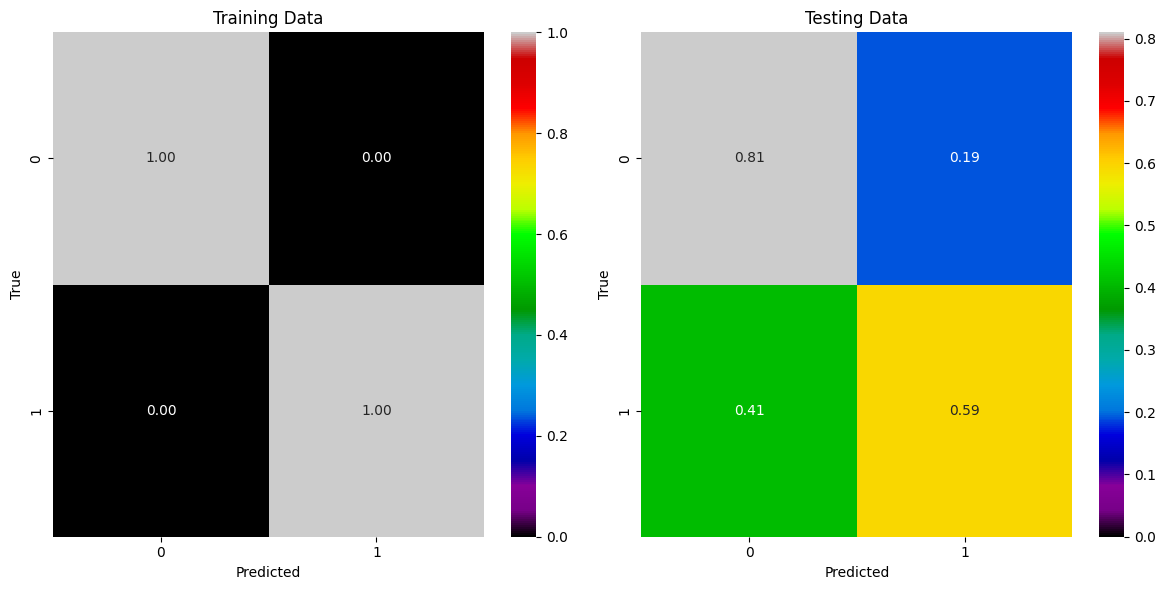

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:10:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



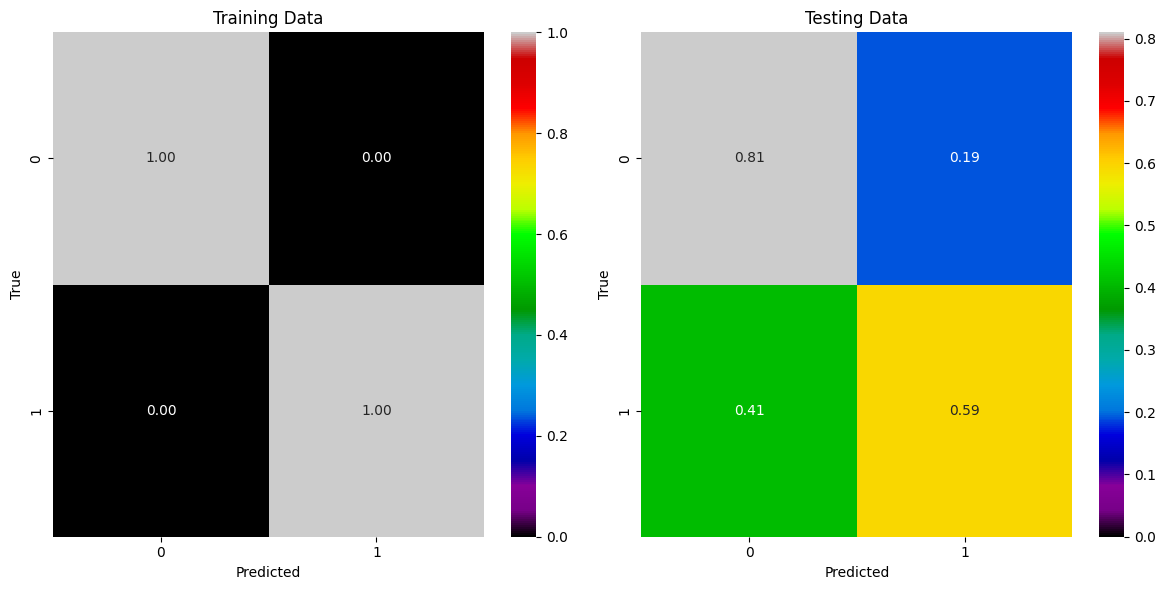

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:10:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



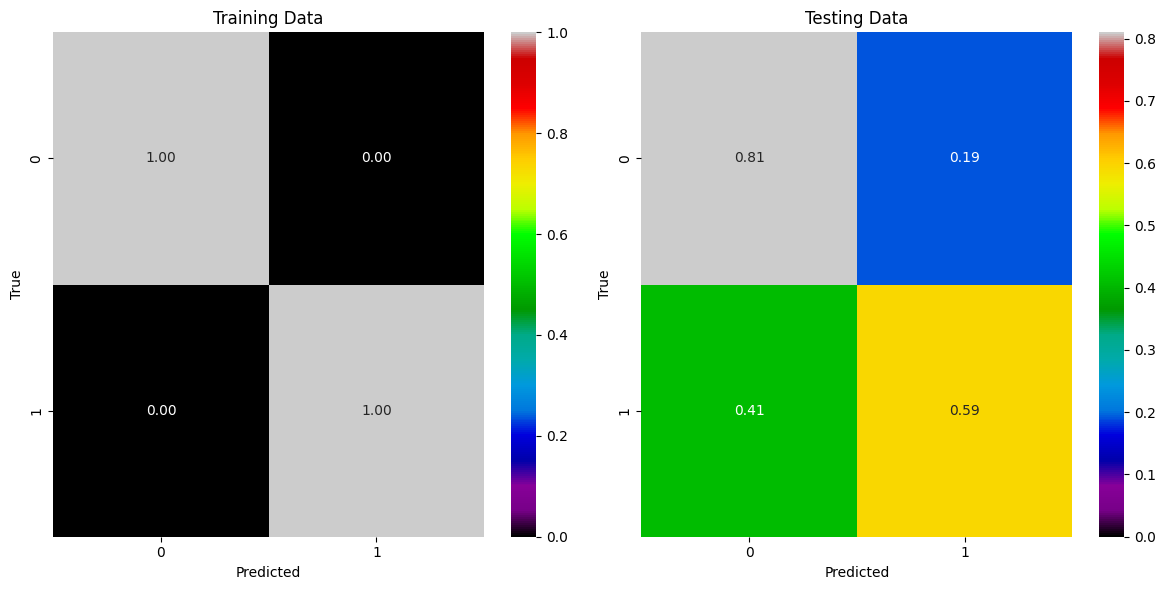


Model: AdaBoostClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



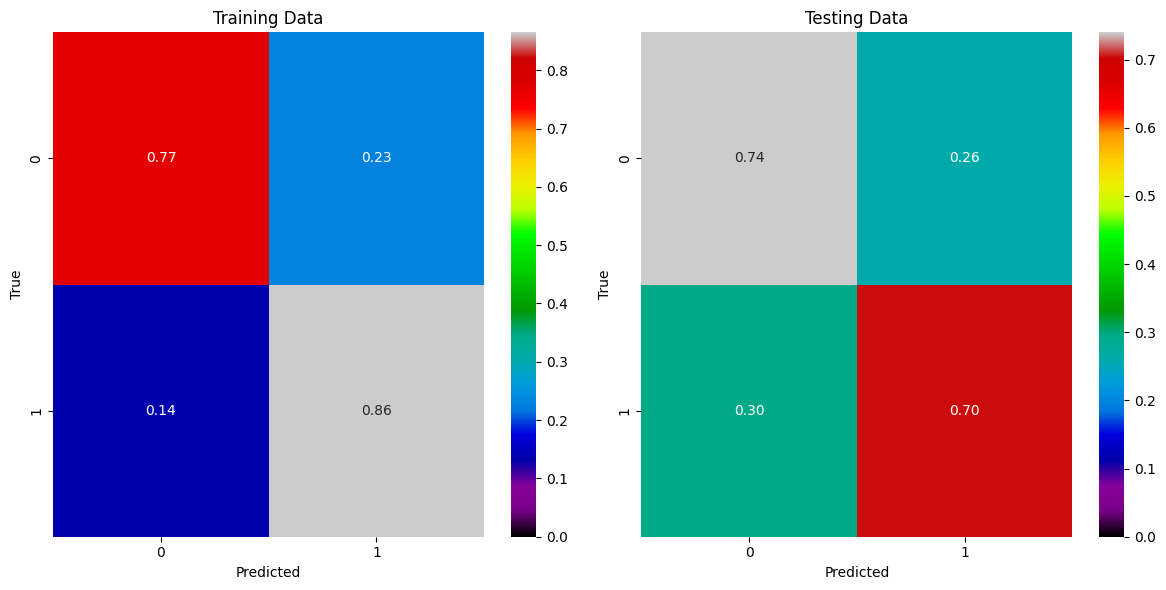


=== Model Comparison (sorted by AUPRC) ===
                                Model    AUPRC    AUROC      MCC       F1
       LogisticRegression(leaves=N/A) 0.745327 0.823519 0.411792 0.625000
 GradientBoostingClassifier(leaves=3) 0.710056 0.822963 0.429630 0.629630
       AdaBoostClassifier(leaves=N/A) 0.689921 0.822407 0.429614 0.644068
    RandomForestClassifier(leaves=30) 0.688919 0.813519 0.400615 0.619469
GradientBoostingClassifier(leaves=10) 0.688737 0.812778 0.389492 0.605505
GradientBoostingClassifier(leaves=30) 0.687315 0.811852 0.389492 0.605505
     RandomForestClassifier(leaves=3) 0.678438 0.811667 0.383707 0.607143
    RandomForestClassifier(leaves=10) 0.666585 0.819074 0.400615 0.619469
     KNeighborsClassifier(leaves=N/A) 0.642342 0.755926 0.349754 0.581818
            XGBClassifier(leaves=N/A) 0.632442 0.777037 0.408187 0.609524
            XGBClassifier(leaves=N/A) 0.632442 0.777037 0.408187 0.609524
            XGBClassifier(leaves=N/A) 0.632442 0.777037 0.408187 0.6

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score, matthews_corrcoef, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = []

for i, m in enumerate(models):
    m.fit(X_train_res, y_train_res)
    y_train_pred = m.predict(X_train_res)
    y_test_pred = m.predict(X_test)

    # Calculate y_prob for the current model
    y_prob = m.predict_proba(X_test)[:, 1]

    auprc = average_precision_score(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    mcc   = matthews_corrcoef(y_test, y_test_pred)
    f1    = f1_score(y_test, y_test_pred)
    name  = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', 'N/A')})"

    results.append({
        'Model': name,
        'AUPRC': auprc,
        'AUROC': auroc,
        'MCC':   mcc,
        'F1':    f1,
    })

    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train_res, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    conf_matrix_train = conf_matrix_train.astype(float)
    conf_matrix_test  = conf_matrix_test.astype(float)
    for row_idx in range(conf_matrix_train.shape[0]):
        if conf_matrix_train[row_idx,:].sum() > 0:
            conf_matrix_train[row_idx,:] = conf_matrix_train[row_idx,:] / conf_matrix_train[row_idx,:].sum()
        if conf_matrix_test[row_idx,:].sum() > 0:
            conf_matrix_test[row_idx,:]  = conf_matrix_test[row_idx,:] / conf_matrix_test[row_idx,:].sum()

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0], cmap='nipy_spectral')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1], cmap='nipy_spectral')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    plt.tight_layout()
    plt.show()

# --- Model comparison table ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('AUPRC', ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by AUPRC) ===")
print(results_df.to_string(index=False))


In [ ]:
! pip install SHAP

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:17:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


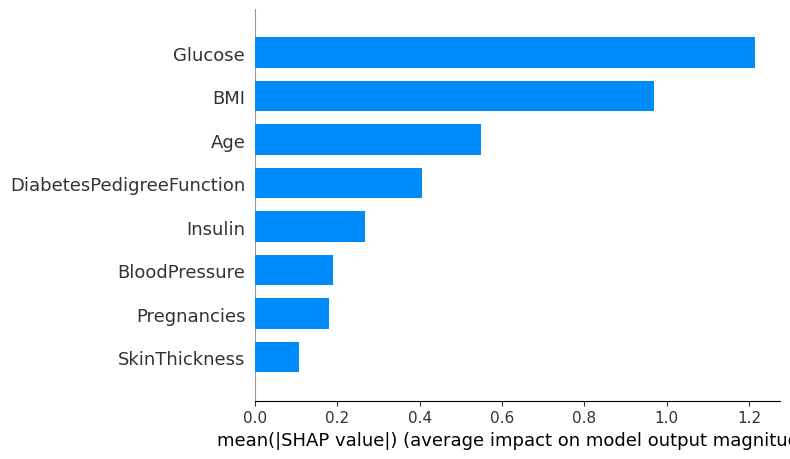

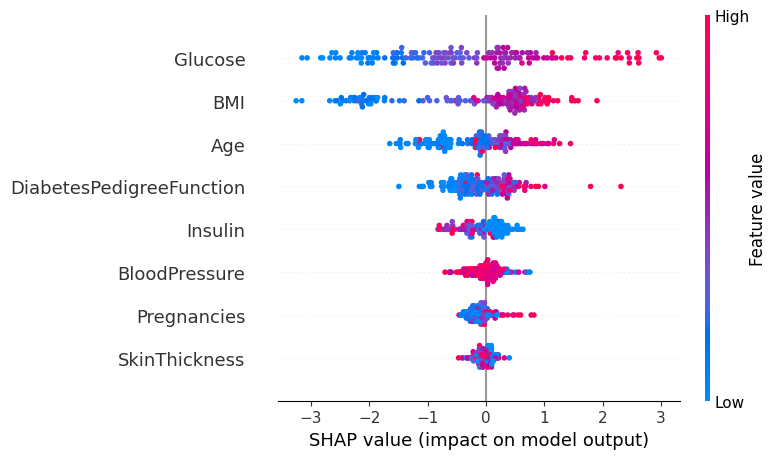

In [ ]:
import shap

# Choose one of the trained models for explanation (e.g., the first XGBoost model)
# model_to_explain = models[9] # This is xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3)
# Or, if you want to use the best performing model from your MLflow run, you would select it here.

# Let's refit the chosen model just to be safe, as the `models` list might not contain fitted versions
model_to_explain = models[13] # Changed to a tree-based model, e.g., xgb.XGBClassifier
model_to_explain.fit(X_train, y_train)

# Create a SHAP explainer
explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary plot (Feature Importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# You can also get a more detailed summary plot
shap.summary_plot(shap_values, X_test)

# Deep Learning

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

dropout_rate = 0.1

n_classes = np.unique(y).shape[0]

# Create model
model = Sequential([
    Input(shape=X.shape[1:]),

    Dense(20, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    #Dense(20, activation='relu'),
    #BatchNormalization(),
    #Dropout(dropout_rate),

    #Dense(20, activation='relu'),
    #BatchNormalization(),
    #Dropout(dropout_rate),

    Dense(20, activation='relu'),

    Dense(n_classes, activation='softmax'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.005)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=100,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722 (2.82 KB)

 Trainable params: 682 (2.66 KB)

 Non-trainable params: 40 (160.00 B)

Training KERAS MODEL

In [ ]:
# Train model
history = model.fit(
    X_train_res, y_train_res,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7825 - loss: 0.4948 - val_accuracy: 0.7273 - val_loss: 0.5265
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.7950 - loss: 0.4550 - val_accuracy: 0.6883 - val_loss: 0.6028
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7900 - loss: 0.4572 - val_accuracy: 0.6688 - val_loss: 0.6821
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7887 - loss: 0.4543 - val_accuracy: 0.6299 - val_loss: 0.7320
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7788 - loss: 0.4519 - val_accuracy: 0.6364 - val_loss: 0.7046
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7925 - loss: 0.4426 - val_accuracy: 0.6688 - val_loss: 0.6547
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7912 - loss: 0.4509 - val_accuracy: 0.7078 - val_loss: 0.6336
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7962 - loss: 0.4482 - val_accuracy: 0.6883 - val_lo

PLOTTING CONFUSION MATRIX and CLASSIFICATION REPORT FOR KERAS MODEL

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


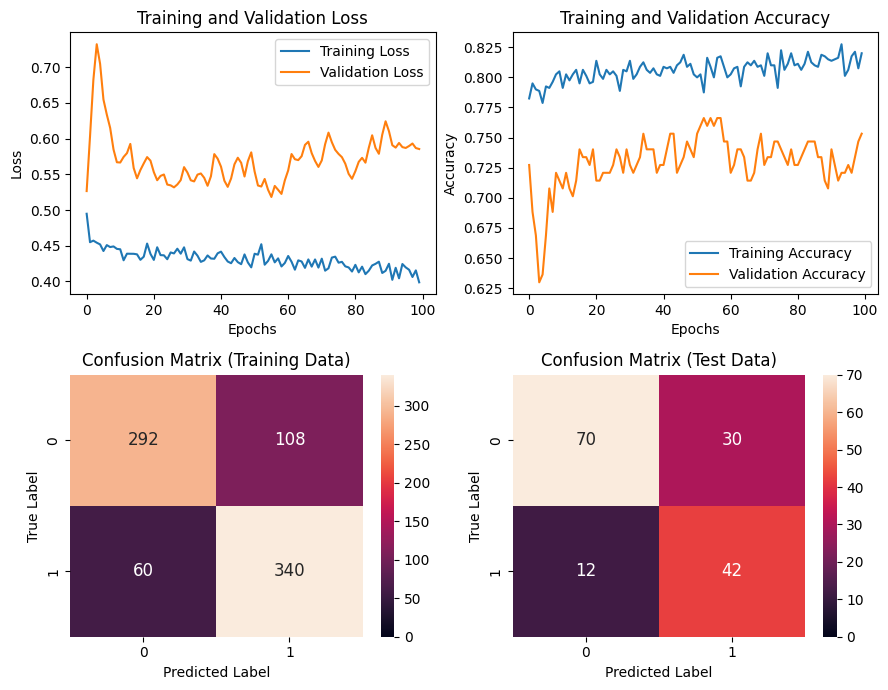

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       100
           1       0.58      0.78      0.67        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.73       154



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_train_pred = model.predict(X_train_res).argmax(axis=1)
y_test_pred  = model.predict(X_test).argmax(axis=1)

# Confusion matrices
cm_train = confusion_matrix(y_train_res, y_train_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Top-left: Training and Validation Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Top-right: Training and Validation Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Bottom-left: Confusion Matrix (Training)
sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1, 0], vmin=0, annot_kws={"size": 12})
axes[1, 0].set_title('Confusion Matrix (Training Data)')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Bottom-right: Confusion Matrix (Test)
sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1, 1], vmin=0, annot_kws={"size": 12})
axes[1, 1].set_title('Confusion Matrix (Test Data)')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Print classification report for test data
print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

Training Multiple ML Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    DecisionTreeClassifier(max_leaf_nodes=3),
    DecisionTreeClassifier(max_leaf_nodes=10),
    DecisionTreeClassifier(max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1)
]

Plotting Confusion matrix and classification report for Multiple ML model

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



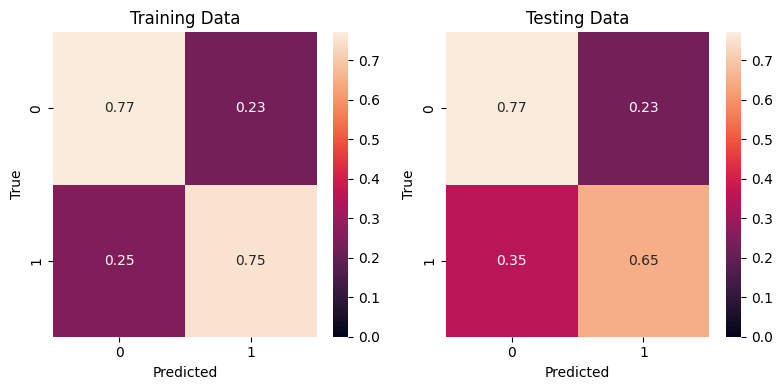

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       100
           1       0.59      0.63      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154



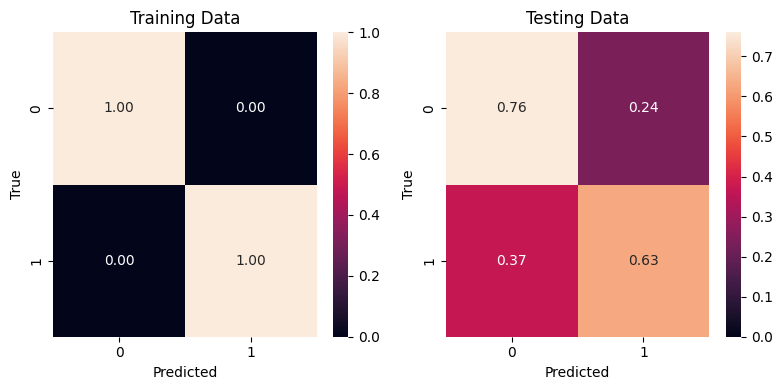

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.78      0.71      0.74       100
           1       0.54      0.63      0.58        54

    accuracy                           0.68       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.70      0.68      0.69       154



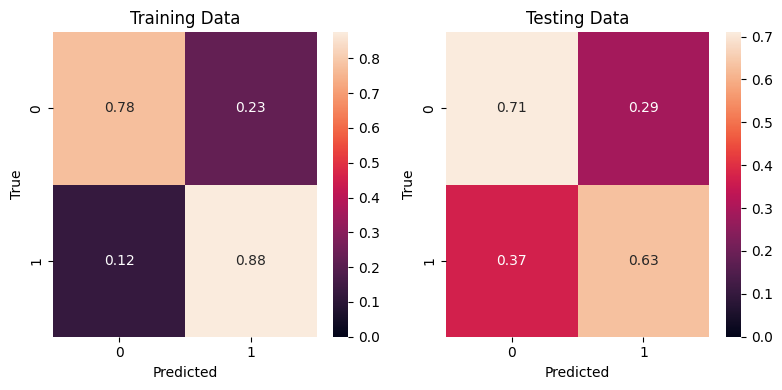

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       100
           1       0.57      0.59      0.58        54

    accuracy                           0.70       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.70      0.70       154



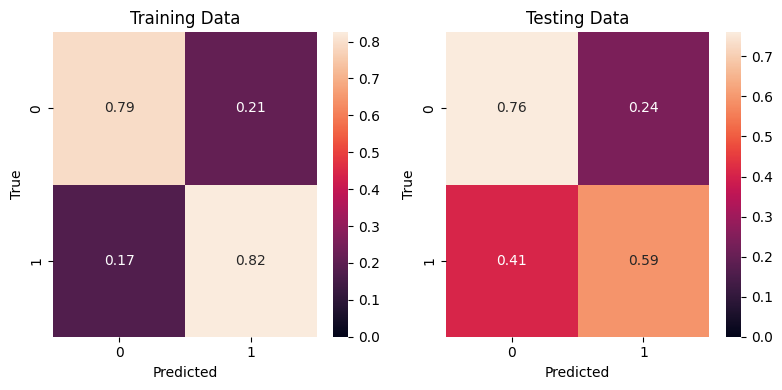

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       100
           1       0.58      0.69      0.63        54

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



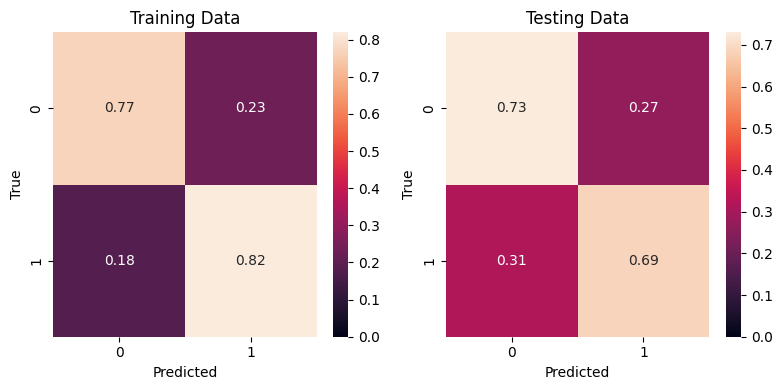

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       100
           1       0.60      0.67      0.63        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.74      0.73      0.73       154



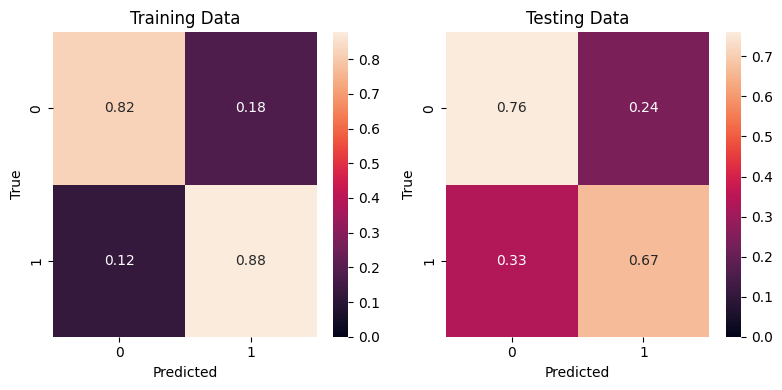

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       100
           1       0.61      0.63      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



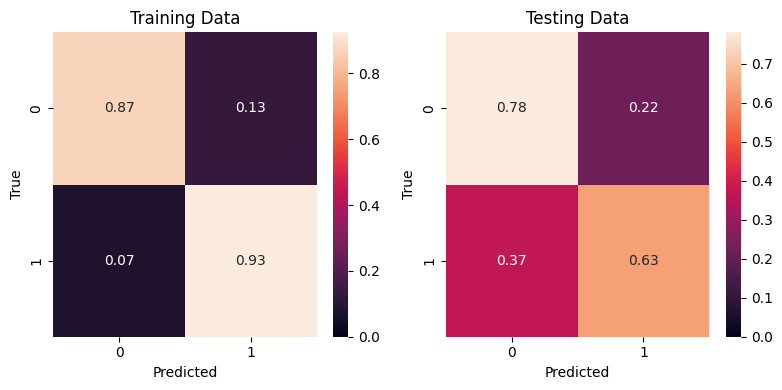

DecisionTreeClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.80      0.68      0.74       100
           1       0.54      0.69      0.60        54

    accuracy                           0.68       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.71      0.68      0.69       154



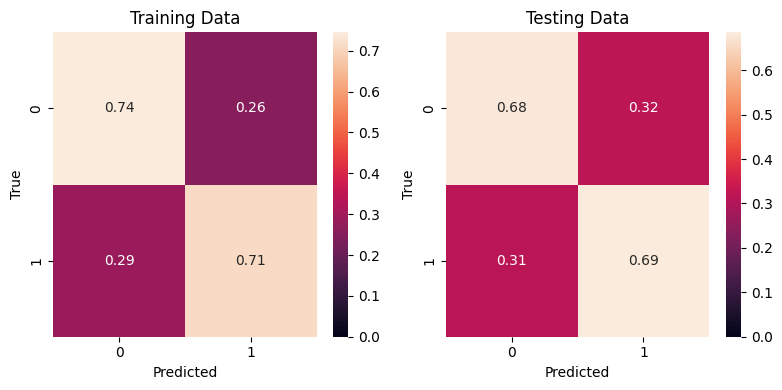

DecisionTreeClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154



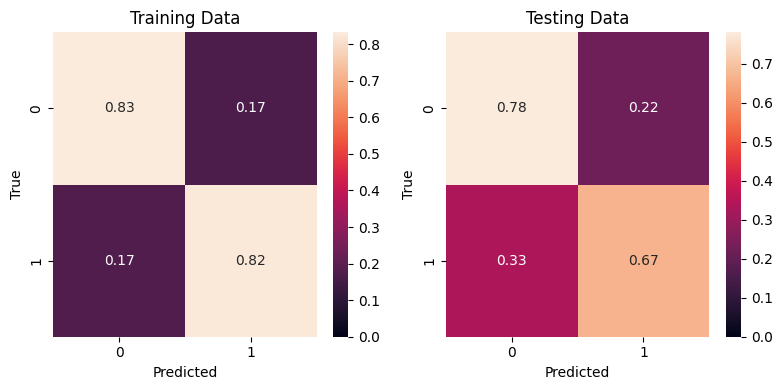

DecisionTreeClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.62      0.59      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



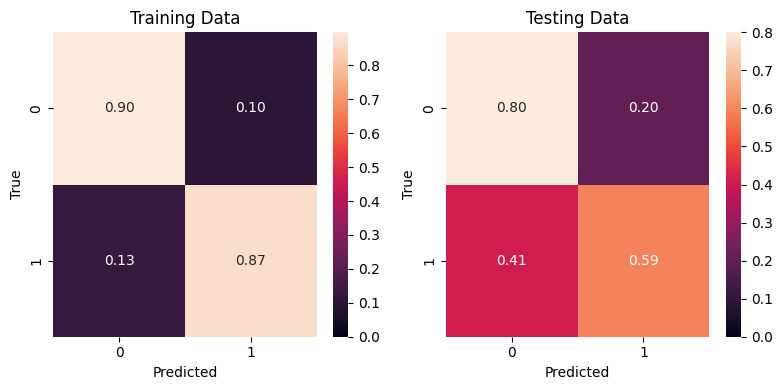

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       100
           1       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



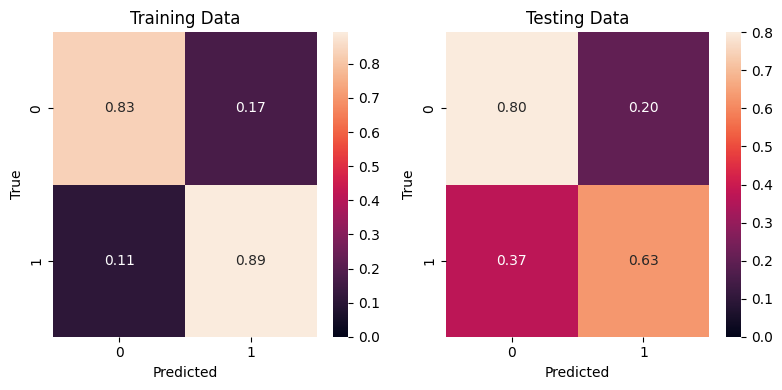

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       100
           1       0.61      0.61      0.61        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



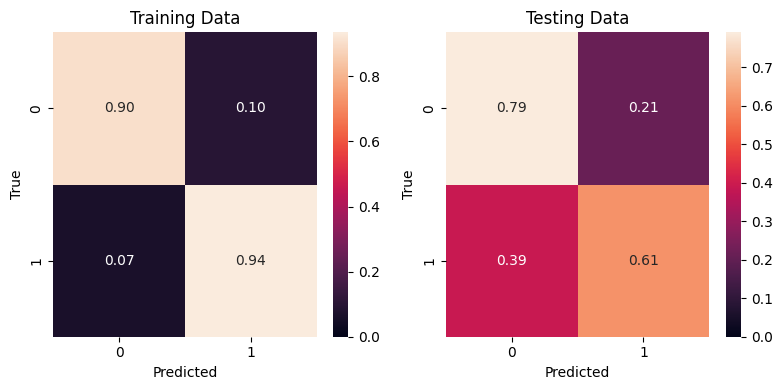

GradientBoostingClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       100
           1       0.60      0.61      0.61        54

    accuracy                           0.72       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.72      0.72       154



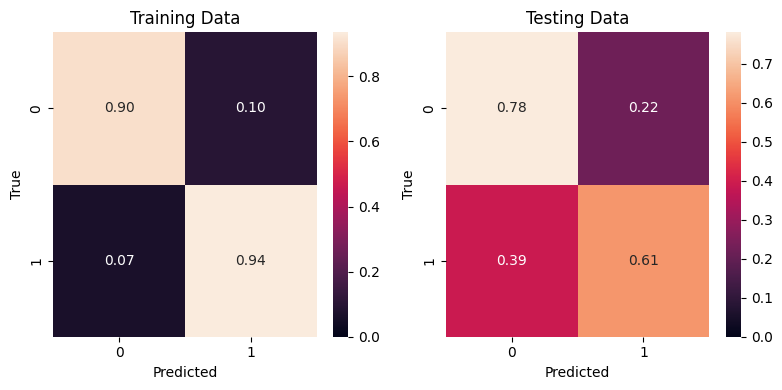

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:33:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=3, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0

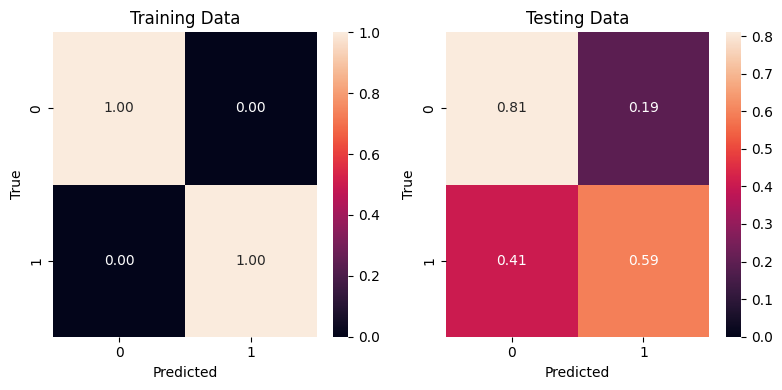

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:33:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=10, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      

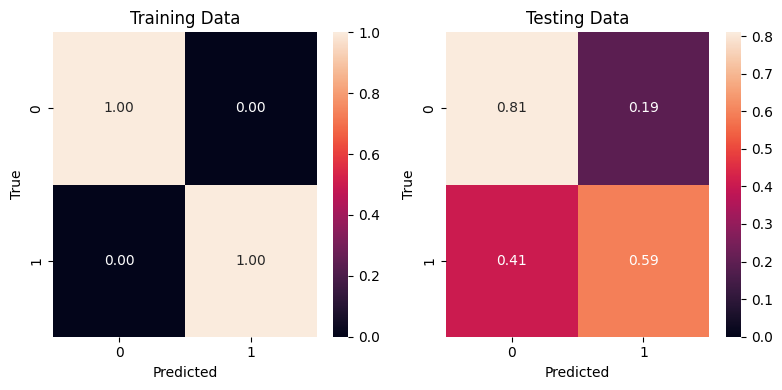

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:33:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      

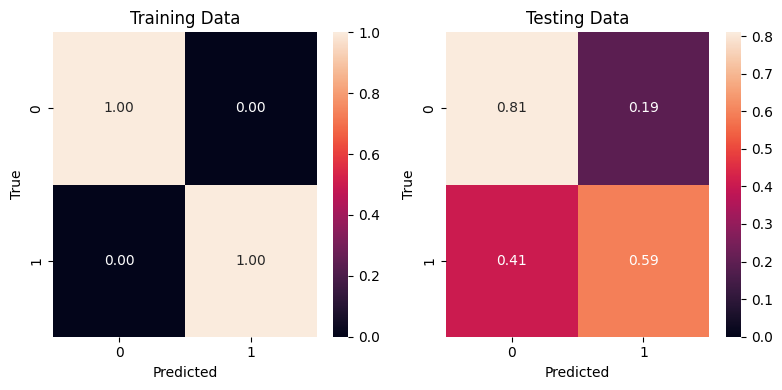

AdaBoostClassifier(learning_rate=0.1, n_estimators=100)
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



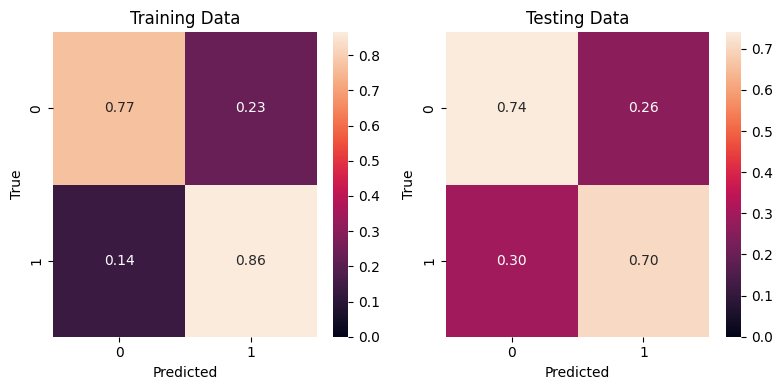

In [ ]:
for m in models:
    # Train the model
    m.fit(X_train_res, y_train_res)

    print(m)

    # Generate predictions
    y_train_pred = m.predict(X_train_res).astype(int)
    y_test_pred = m.predict(X_test).astype(int)

    # Print classification report
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train_res, y_train_pred).astype(float)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(float)

    # Normalize confusion matrices
    for i in range(conf_matrix_train.shape[0]):
        conf_matrix_train[i, :] /= conf_matrix_train[i, :].sum()
        conf_matrix_test[i, :] /= conf_matrix_test[i, :].sum()

    # Create subplots for confusion matrices
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end

#KERAS Cross Validation

analyze the Keras Sequential model's performance on unseen data by creating multiple training and validation splits. This provides a much more robust and reliable estimate of your Keras model's generalization capability than a single train-validation split.


==================== Fold 1/10 ====================


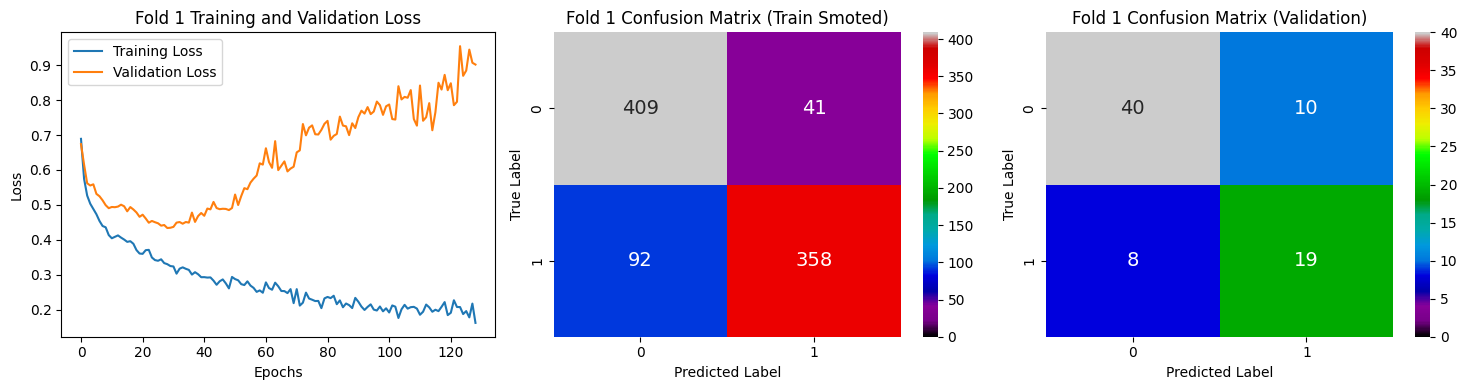

Classification Report (Validation Data - Fold 1):
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        50
           1       0.66      0.70      0.68        27

    accuracy                           0.77        77
   macro avg       0.74      0.75      0.75        77
weighted avg       0.77      0.77      0.77        77


==================== Fold 2/10 ====================


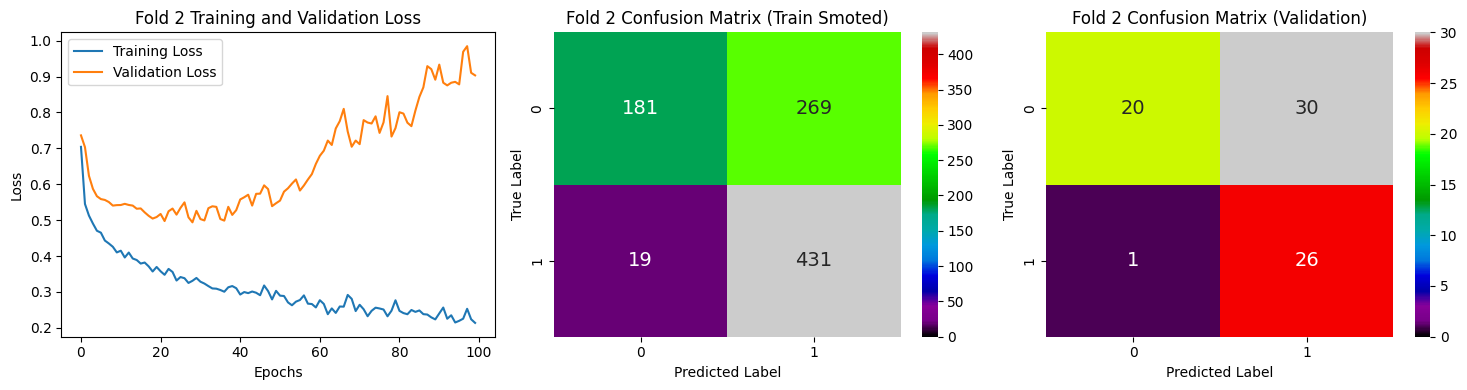

Classification Report (Validation Data - Fold 2):
              precision    recall  f1-score   support

           0       0.95      0.40      0.56        50
           1       0.46      0.96      0.63        27

    accuracy                           0.60        77
   macro avg       0.71      0.68      0.59        77
weighted avg       0.78      0.60      0.59        77


==================== Fold 3/10 ====================


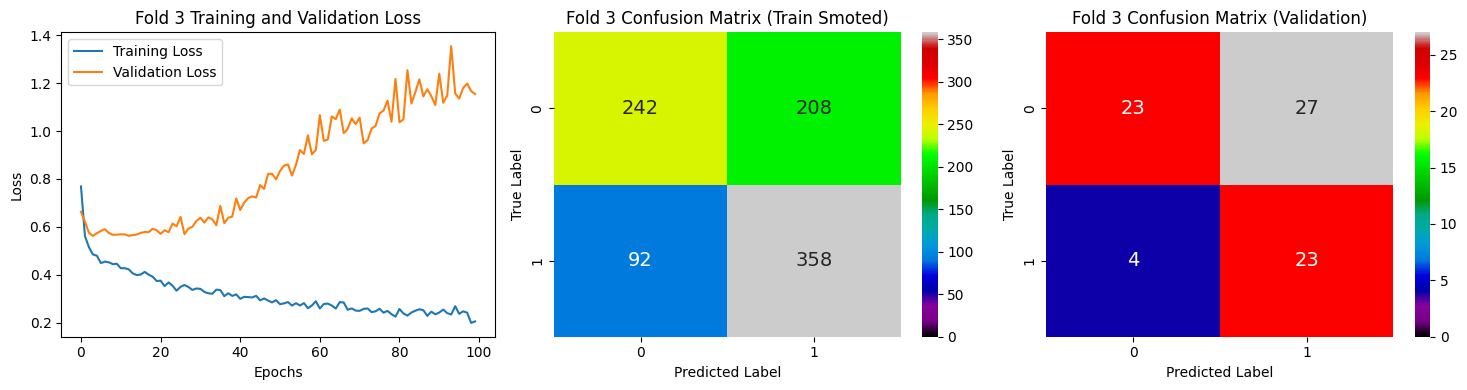

Classification Report (Validation Data - Fold 3):
              precision    recall  f1-score   support

           0       0.85      0.46      0.60        50
           1       0.46      0.85      0.60        27

    accuracy                           0.60        77
   macro avg       0.66      0.66      0.60        77
weighted avg       0.71      0.60      0.60        77


==================== Fold 4/10 ====================


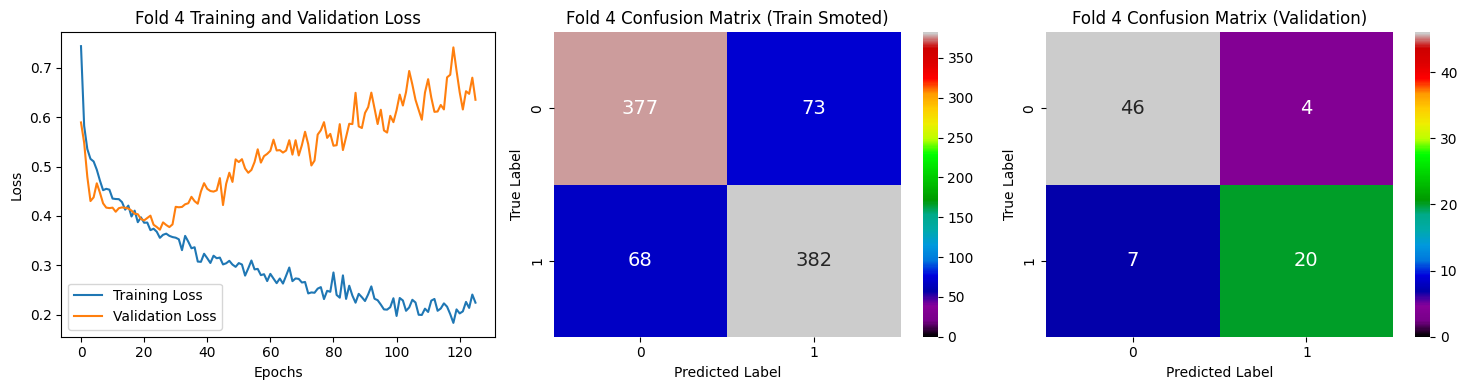

Classification Report (Validation Data - Fold 4):
              precision    recall  f1-score   support

           0       0.87      0.92      0.89        50
           1       0.83      0.74      0.78        27

    accuracy                           0.86        77
   macro avg       0.85      0.83      0.84        77
weighted avg       0.86      0.86      0.86        77


==================== Fold 5/10 ====================


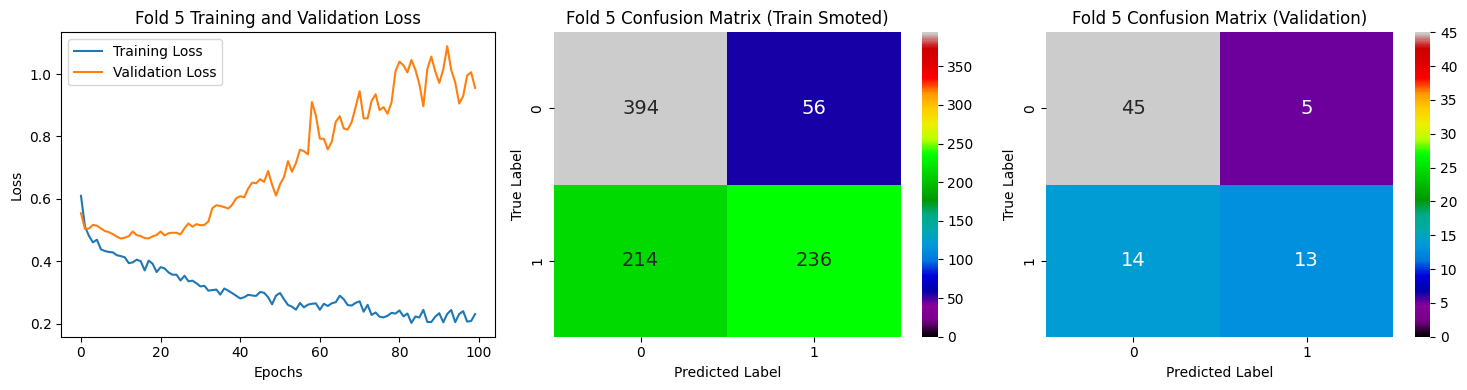

Classification Report (Validation Data - Fold 5):
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        50
           1       0.72      0.48      0.58        27

    accuracy                           0.75        77
   macro avg       0.74      0.69      0.70        77
weighted avg       0.75      0.75      0.74        77


==================== Fold 6/10 ====================


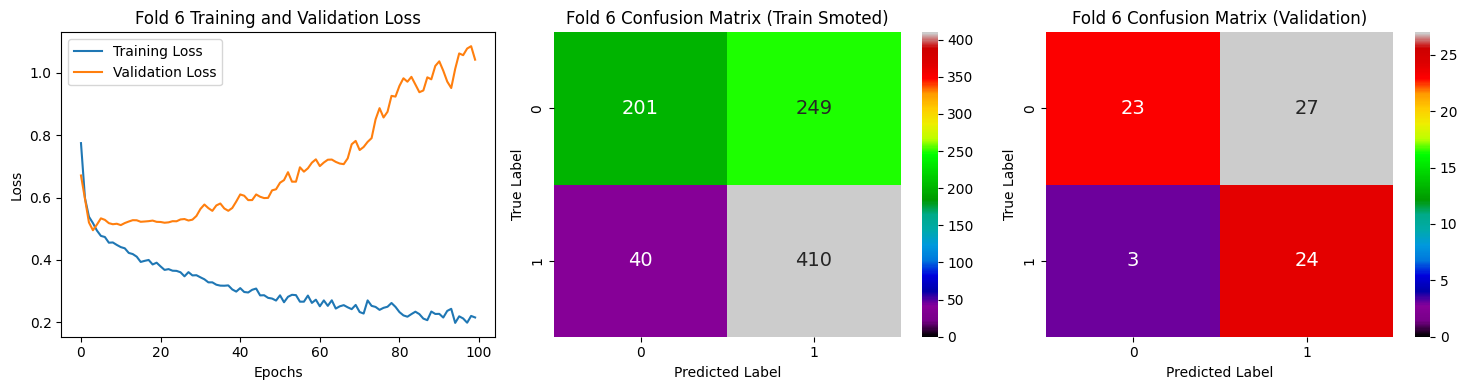

Classification Report (Validation Data - Fold 6):
              precision    recall  f1-score   support

           0       0.88      0.46      0.61        50
           1       0.47      0.89      0.62        27

    accuracy                           0.61        77
   macro avg       0.68      0.67      0.61        77
weighted avg       0.74      0.61      0.61        77


==================== Fold 7/10 ====================


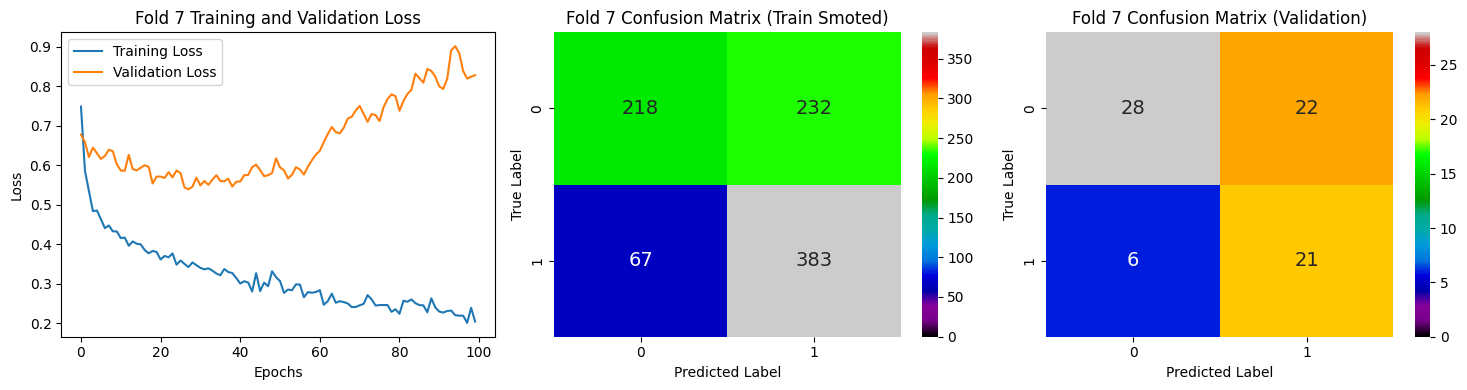

Classification Report (Validation Data - Fold 7):
              precision    recall  f1-score   support

           0       0.82      0.56      0.67        50
           1       0.49      0.78      0.60        27

    accuracy                           0.64        77
   macro avg       0.66      0.67      0.63        77
weighted avg       0.71      0.64      0.64        77


==================== Fold 8/10 ====================


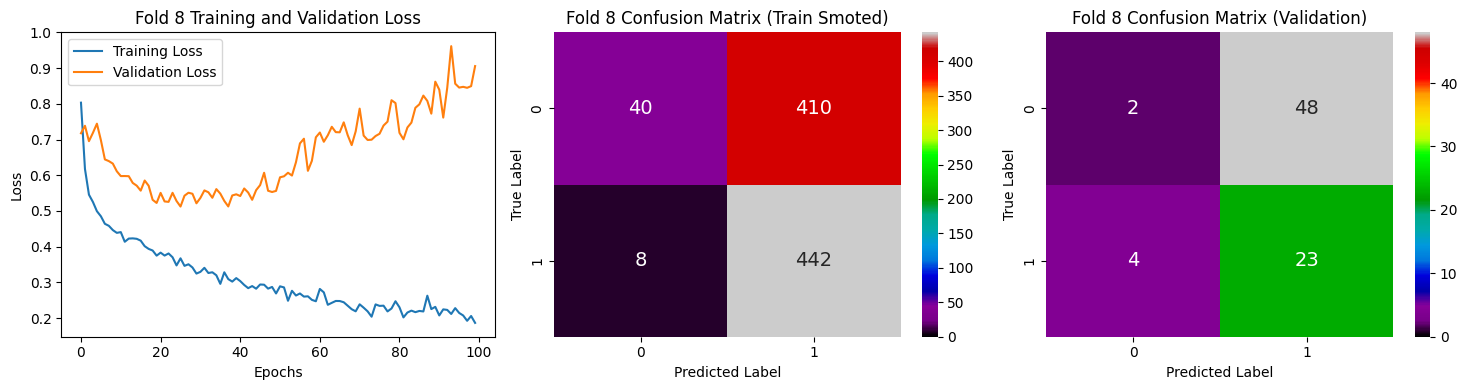

Classification Report (Validation Data - Fold 8):
              precision    recall  f1-score   support

           0       0.33      0.04      0.07        50
           1       0.32      0.85      0.47        27

    accuracy                           0.32        77
   macro avg       0.33      0.45      0.27        77
weighted avg       0.33      0.32      0.21        77


==================== Fold 9/10 ====================


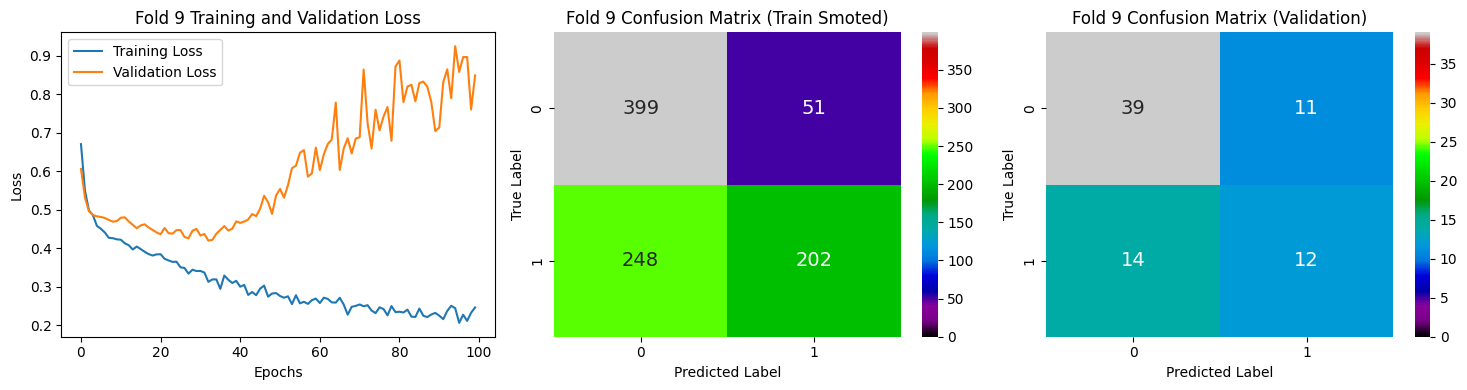

Classification Report (Validation Data - Fold 9):
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        50
           1       0.52      0.46      0.49        26

    accuracy                           0.67        76
   macro avg       0.63      0.62      0.62        76
weighted avg       0.66      0.67      0.67        76


==================== Fold 10/10 ====================


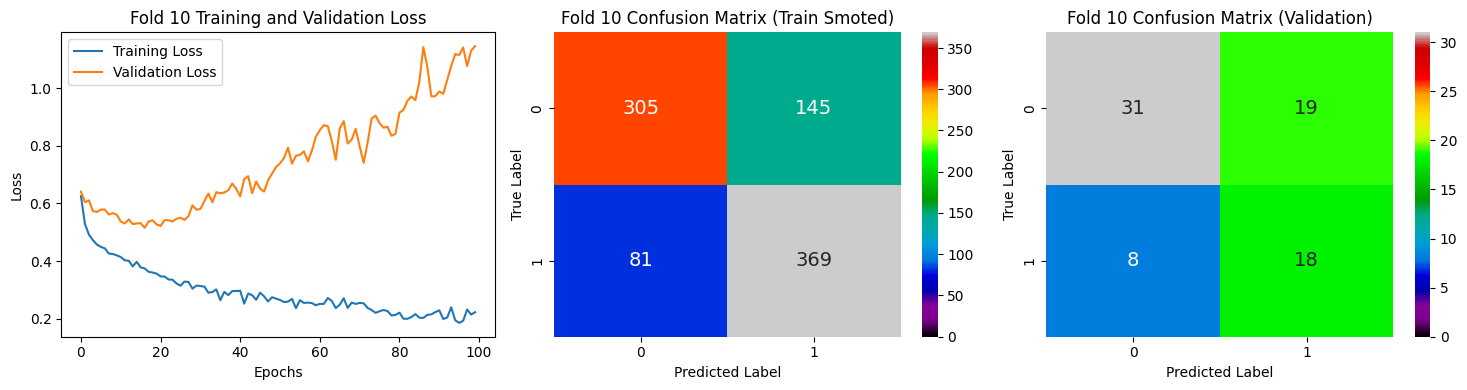

Classification Report (Validation Data - Fold 10):
              precision    recall  f1-score   support

           0       0.79      0.62      0.70        50
           1       0.49      0.69      0.57        26

    accuracy                           0.64        76
   macro avg       0.64      0.66      0.63        76
weighted avg       0.69      0.64      0.65        76


==================== Cross-Validation Summary ====================
Average Validation Accuracy across 10 folds: 0.6459
Average Macro F1-score across 10 folds: 0.6252
Standard Deviation of Validation Accuracy: 0.1344
Standard Deviation of Macro F1-score: 0.1394


In [ ]:
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Ensure pandas is imported for .iloc

splits = 10 # Number of folds

dropout_rate = 0.1
n_classes = np.unique(y).shape[0] # Number of unique classes in the target variable

learning_rate = 0.01

# Early stopping callback to prevent overfitting and restore best weights
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=100,         # Stop if validation loss doesn't improve for 100 epochs
    restore_best_weights=True # Restore the model weights from the epoch with the best validation loss
)

# Initialize Stratified K-Fold to maintain class proportions in each split
kf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42) # Added random_state for reproducibility

fold_results = [] # List to store results from each fold

# Iterate through each fold generated by StratifiedKFold
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    tf.keras.backend.clear_session() # Clear Keras session for a fresh model in each fold

    print(f"\n{'='*20} Fold {fold+1}/{splits} {'='*20}")

    # Split data for the current fold using the indices from StratifiedKFold
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Initialize StandardScaler and SMOTE for each fold to prevent data leakage
    std_scaler_fold = StandardScaler() # Scales features to have zero mean and unit variance
    smote_fold = SMOTE(sampling_strategy='auto', k_neighbors=20, random_state=42) # Over-samples minority class (k_neighbors=20 from original Keras cell)

    # 1. Scale the data: fit on training data of current fold, then transform both training and validation data
    X_train_scaled = std_scaler_fold.fit_transform(X_train_fold)
    X_val_scaled = std_scaler_fold.transform(X_val_fold)

    # 2. Apply SMOTE only to the *scaled* training data of the current fold to balance classes
    X_train_smoted, y_train_smoted = smote_fold.fit_resample(X_train_scaled, y_train_fold)

    # Build Keras model (architecture identical to cell VmAjjxvZthrC)
    model = Sequential([
        Input(shape=X.shape[1:]), # Input shape is the number of original features (8 in this case)
        Dense(20, activation='relu'), # First hidden layer with ReLU activation
        BatchNormalization(), # Normalizes activations of previous layer
        Dropout(dropout_rate), # Randomly sets a fraction of input units to 0 at each update during training
        Dense(20, activation='relu'), # Second hidden layer with ReLU activation
        Dense(20, activation='relu'), # Third hidden layer with ReLU activation
        Dense(n_classes, activation='softmax'), # Output layer with softmax for multi-class probability distribution
    ])

    # Define the optimizer with a custom learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile model with appropriate loss function and metrics for binary classification
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy', # Appropriate for integer labels (0 or 1) and softmax output
        metrics=['accuracy'] # Monitor accuracy during training
    )

    # Train the model on the SMOTEd and scaled training data
    history = model.fit(
        X_train_smoted, y_train_smoted,
        epochs=1000, # Maximum number of epochs, early stopping will stop training if no improvement
        batch_size=256,
        validation_data=(X_val_scaled, y_val_fold), # Evaluate on scaled validation data
        callbacks=[early_stopping],
        verbose=0, # Set to 0 to suppress output for each epoch, only print fold summary
    )

    # --- Evaluate Model for Current Fold --- (on best weights due to EarlyStopping)
    # Get predictions for training and validation data
    y_train_pred_probs = model.predict(X_train_smoted, verbose=0)
    y_train_pred = np.argmax(y_train_pred_probs, axis=1)

    y_val_pred_probs = model.predict(X_val_scaled, verbose=0)
    y_val_pred  = np.argmax(y_val_pred_probs, axis=1)

    # Compute confusion matrices for both training and validation sets
    cm_train = confusion_matrix(y_train_smoted, y_train_pred)
    cm_val = confusion_matrix(y_val_fold, y_val_pred)

    # Generate classification report for validation data to get detailed metrics
    report_val = classification_report(y_val_fold, y_val_pred, output_dict=True, zero_division=0)
    fold_accuracy = report_val['accuracy']
    fold_f1_macro = report_val['macro avg']['f1-score']

    # Store results for this fold
    fold_results.append({
        'fold': fold + 1,
        'accuracy': fold_accuracy,
        'f1_macro': fold_f1_macro,
        'train_history': history,
        'cm_train': cm_train,
        'cm_val': cm_val,
        'report_val': report_val
    })

    # Plot results for this individual fold
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Left subplot: Training and Validation Loss over epochs
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'Fold {fold+1} Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Middle subplot: Confusion Matrix for the SMOTEd training data
    sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1], vmin=0, annot_kws={"size": 14}, cmap='nipy_spectral')
    axes[1].set_title(f'Fold {fold+1} Confusion Matrix (Train Smoted)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    # Right subplot: Confusion Matrix for the validation data of the current fold
    sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[2], vmin=0, annot_kws={"size": 14}, cmap='nipy_spectral')
    axes[2].set_title(f'Fold {fold+1} Confusion Matrix (Validation)')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

    print(f"Classification Report (Validation Data - Fold {fold+1}):")
    print(classification_report(y_val_fold, y_val_pred, zero_division=0))

# --- Summarize all folds after the loop completes ---
print(f"\n{'='*20} Cross-Validation Summary {'='*20}")
# Calculate average accuracy and F1-score across all folds
avg_accuracy = np.mean([res['accuracy'] for res in fold_results])
avg_f1_macro = np.mean([res['f1_macro'] for res in fold_results])
print(f"Average Validation Accuracy across {splits} folds: {avg_accuracy:.4f}")
print(f"Average Macro F1-score across {splits} folds: {avg_f1_macro:.4f}")

# Optional: Display standard deviation for a better understanding of variability
std_accuracy = np.std([res['accuracy'] for res in fold_results])
std_f1_macro = np.std([res['f1_macro'] for res in fold_results])
print(f"Standard Deviation of Validation Accuracy: {std_accuracy:.4f}")
print(f"Standard Deviation of Macro F1-score: {std_f1_macro:.4f}")